# DepMap Mutation 기반 유전체 불안정성(WGD/CIN/LOH) 예측 — 전체 파이프라인

DepMap Public 26Q1 / 1,631개 세포주 / hotspot 554 + damaging 19,578 mutation feature 로
Whole Genome Doubling(WGD), Chromosomal Instability(CIN), Loss of Heterozygosity(LOH)를
예측하고, 최소 mutation biomarker panel을 찾는 프로젝트의 전체 파이프라인이다.

전체 코드/문서: https://github.com/lkeonwoo94/AI-bio-proj-team-1

**노트북 구성**
0. 실행 환경 준비 (저장소 클론 / 데이터 확보)
1. 데이터 로드 & 코호트 요약
2. EDA — mutation/표현형 분포
3. 모델 비교 (Logistic/Elastic Net/Random Forest/XGBoost/CatBoost/Multi-task ANN)
4. 최고 성능 모델(Random Forest) confusion matrix
5. 반복 feature selection — 어떤 mutation이 중요한가
6. 최소 mutation panel — 몇 개까지 줄여도 되는가
7. Lineage(암종) 일반화 — GroupKFold / Leave-One-Lineage-Out
8. CIN/LOH 이진화가 정보를 버리는가 — 회귀로 직접 검증
9. Pathway 단위 재집계 (실행 결과 — 음성)
10. Mutation signature(96-class) 표현 (실행 결과 — 양성)
11. 유전자 + Signature 결합 패널
12. Sensitivity/Specificity 트레이드오프
13. TCGA 외부 코호트 검증
14. 탐색적 분석 — 연관성 검정 / UMAP / CCA / 군집
15. 최종 후보 Biomarker Panel
16. 결론 및 한계

**이 노트북이 직접 계산하는 것**

* **3절 모델 비교** — outer 5-fold × inner 5-fold nested CV 를 여기서 실제로 학습한다.
  `RUN_MODELS` 로 범위를 조절한다.
* **4절 confusion matrix**, **5절 feature selection** — 3절 학습이 남긴 test 예측과
  fold 별 중요도를 재사용하므로 추가 학습이 없다.
* **14절 탐색적 분석** — 연관성 검정, UMAP, CCA, 군집 모두 여기서 계산한다.

**결과를 불러오는 것**

6\~13절(패널 곡선, lineage 검증, 회귀, pathway, signature, 결합 패널, TCGA)은
`scripts/` 가 이미 계산해 `results/tables/`·`results/figures/` 에 저장해 둔 결과
(git 에 커밋됨)를 읽어 그림만 다시 그린다. 각각 수 분\~십수 분씩 걸려 노트북을 열
때마다 돌리기에는 비현실적이다. 각 절에 재현용 커맨드를 적어두었다.

모든 계산은 §13 원칙에 따라 outer test 데이터가 threshold/feature selection
어디에도 관여하지 않도록 leakage 를 방지한다.

## 0. 실행 환경 준비 (로컬 / Google Colab 공용)

아래 셀이 순서대로 처리한다.

1. **저장소** — 이미 저장소 안이면 그대로 쓰고, 아니면(Colab 등) `git clone` 한다.
   이 노트북은 `src/` 의 파이프라인 코드를 그대로 import 해서 쓴다. 그래야
   여기서 나오는 수치가 저장소 결과와 **구조적으로 같다** (코드가 두 벌이 아니다).
2. **데이터** — `data/interim/cohort_*.parquet` 또는 `data/depmap/*.csv` 가 로컬에
   있으면 그것을 쓰고, 없으면 **공개 Google Drive 폴더에서 내려받는다**.
   드라이브 *마운트* 가 아니라 다운로드라서, 폴더 주인이 아닌 사람도 그대로 실행된다.
3. **패키지·한글 폰트** — Colab 에 없는 것만 설치한다.

In [1]:
# --- 저장소 + 데이터 준비 ---
import os
import shutil
import time
import subprocess
import sys
from pathlib import Path

REPO_URL = "https://github.com/lkeonwoo94/AI-bio-proj-team-1.git"
# 공개 폴더. 마운트가 아니라 다운로드라서 폴더 주인이 아니어도 받을 수 있다.
DRIVE_FOLDER_URL = "https://drive.google.com/drive/folders/1WKn7V26f4ETRZgH_5TcjcIPdlO9L6j2h"

IN_COLAB = "google.colab" in sys.modules

RAW_FILES = ["OmicsSomaticMutationsMatrixHotspot.csv",
             "OmicsSomaticMutationsMatrixDamaging.csv",
             "OmicsGlobalSignatures.csv", "Model.csv"]
CACHE_FILES = ["cohort_X.parquet", "cohort_y.parquet", "cohort_groups.parquet"]
# signature(96-class) 행렬. 이미 만들어져 있어 hg38.2bit(800MB) 없이도 쓸 수 있다.
EXTRA_FILES = ["sbs96_signature_matrix.parquet"]
# TCGA 외부 검증용 파생 데이터. 이것도 이미 만들어져 있어 750MB MAF 없이 쓸 수 있다.
TCGA_FILES = ["tcga_damaging_matrix.parquet", "tcga_wgd_labels.parquet"]


def _find_repo_root():
    """src/ 와 results/tables 를 함께 가진 디렉터리를 저장소 루트로 본다."""
    for cand in (Path.cwd(), *Path.cwd().parents):
        if (cand / "src").is_dir() and (cand / "results" / "tables").is_dir():
            return cand
    return None


SCRATCH_CLONE = Path("/content/AI-bio-proj-team-1")   # Colab 에서 우리가 만드는 임시 클론

root = _find_repo_root()
if root is None or (IN_COLAB and root == SCRATCH_CLONE):
    target = SCRATCH_CLONE if IN_COLAB else Path.cwd() / "AI-bio-proj-team-1"
    if not target.is_dir():
        print("저장소를 클론한다...")
        subprocess.run(["git", "clone", "--depth", "1", REPO_URL, str(target)], check=True)
    else:
        # 런타임에 옛 클론이 남아 있으면 노트북(=GitHub 최신)과 src/ 버전이 어긋나
        # AttributeError 같은 게 난다. 그래서 항상 origin/main 으로 맞춘다.
        # 이 디렉터리는 우리가 만든 임시 클론이라 로컬 수정을 버려도 된다.
        print("기존 클론을 origin/main 으로 갱신한다...")
        subprocess.run(["git", "-C", str(target), "fetch", "--depth", "1", "origin", "main"],
                       check=False)
        subprocess.run(["git", "-C", str(target), "reset", "--hard", "origin/main"],
                       check=False, capture_output=True)
        # 갱신이 실패했는데(네트워크·얕은 클론 문제 등) 조용히 넘어가면 옛 src 로
        # 돌다가 엉뚱한 곳에서 터진다. 노트북이 기대하는 기능이 있는지 직접 확인하고,
        # 없으면 클론을 지우고 다시 받는다.
        _nested = target / "src" / "cv" / "nested.py"
        _stale = (not _nested.exists()) or ("predictions" not in _nested.read_text(encoding="utf-8"))
        if _stale:
            print("  클론이 여전히 옛 버전이다 — 지우고 새로 받는다.")
            shutil.rmtree(target, ignore_errors=True)
            subprocess.run(["git", "clone", "--depth", "1", REPO_URL, str(target)], check=True)
    os.chdir(target)
    root = target
    _head = subprocess.run(["git", "-C", str(target), "log", "-1", "--format=%h %s"],
                           capture_output=True, text=True).stdout.strip()
    print("저장소 커밋:", _head)

# 이미 src 를 import 한 뒤라면 파이썬이 옛 모듈을 캐시하고 있어 갱신이 반영되지 않는다.
if any(m.startswith("src.") for m in sys.modules):
    print("주의: src 가 이미 import 돼 있다 — 런타임을 다시 시작하고 처음부터 실행해야 "
          "갱신된 코드가 적용된다.")

REPO_ROOT = root
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))   # src/ 를 import 하기 위해
print("REPO_ROOT:", REPO_ROOT)

DEPMAP = REPO_ROOT / "data" / "depmap"
INTERIM = REPO_ROOT / "data" / "interim"


def _have(directory, names):
    return all((directory / n).exists() for n in names)


def _copy_found(src_root, names, dest):
    """src_root 아래를 재귀 탐색해 이름이 맞는 파일을 dest 로 옮긴다.

    드라이브 폴더 구조를 몰라도(중첩돼 있어도) 파일명으로 찾아낸다.
    """
    dest.mkdir(parents=True, exist_ok=True)
    wanted, n = set(names), 0
    for path in src_root.rglob("*"):
        if path.is_file() and path.name in wanted and not (dest / path.name).exists():
            shutil.copy2(path, dest / path.name)
            print(f"  배치: {path.name} ({path.stat().st_size / 1e6:.0f}MB)")
            n += 1
    return n


if _have(INTERIM, CACHE_FILES) or _have(DEPMAP, RAW_FILES):
    print("데이터: 로컬에 이미 있다 — 드라이브는 건드리지 않는다.")
else:
    print("데이터: 로컬에 없다 — 공개 드라이브 폴더에서 필요한 파일만 받는다.")
    try:
        import gdown
    except ImportError:
        subprocess.run([sys.executable, "-m", "pip", "-q", "install", "gdown"], check=False)
        import gdown

    # 폴더를 통째로 받지 않는다. 이 폴더에는 hg38.2bit(800MB), MC3 MAF(750MB),
    # OmicsSomaticMutations.csv(581MB), 그리고 윈도우가 만든 *Zone.Identifier
    # 부산물까지 들어 있어 2GB 가 넘는다. 전부 받으면 구글이 연속 요청을 막아
    # "Cannot retrieve the public link / have had many accesses" 로 실패한다.
    # 그래서 목록만 먼저 받아(skip_download) 필요한 파일만 골라 내려받는다.
    _t0 = time.time()
    listing = gdown.download_folder(url=DRIVE_FOLDER_URL, skip_download=True,
                                    quiet=True, use_cookies=False) or []
    by_name = {}
    for item in listing:
        by_name.setdefault(Path(item.path).name, item.id)
    print(f"드라이브 폴더에 파일 {len(by_name)}개")

    # 코호트 캐시(14MB)가 있으면 그것만 받는다. 없을 때만 원본 CSV 를 받는다.
    if all(n in by_name for n in CACHE_FILES):
        plan = [(n, INTERIM) for n in CACHE_FILES]
    else:
        plan = [(n, DEPMAP) for n in RAW_FILES]
    plan += [(n, DEPMAP) for n in EXTRA_FILES]      # signature 행렬 (0.7MB)
    plan += [(n, REPO_ROOT / "data" / "gdc") for n in TCGA_FILES]   # TCGA 파생 데이터

    for name, dest in plan:
        if name not in by_name or (dest / name).exists():
            continue
        dest.mkdir(parents=True, exist_ok=True)
        gdown.download(id=by_name[name], output=str(dest / name), quiet=False)
    print(f"다운로드 완료: {time.time() - _t0:.0f}초")

    if not (_have(INTERIM, CACHE_FILES) or _have(DEPMAP, RAW_FILES)):
        raise FileNotFoundError(
            "드라이브에서 데이터를 받지 못했다.\n"
            f"  {DRIVE_FOLDER_URL} 가 '링크가 있는 모든 사용자' 로 공개돼 있는지 확인하거나,\n"
            f"  파일을 직접 {DEPMAP} 에 올린다. 필요한 파일: {RAW_FILES}")

HAS_SIGNATURE = _have(DEPMAP, EXTRA_FILES)
print(f"  signature(96-class) 행렬: {'있음' if HAS_SIGNATURE else '없음'}")

# --- Colab 이면 부족한 패키지와 한글 폰트를 설치한다 ---
if IN_COLAB:
    for pkg, mod in [("pyyaml", "yaml"), ("umap-learn==0.5.6", "umap"),
                     ("xgboost", "xgboost"), ("catboost", "catboost"), ("seaborn", "seaborn")]:
        try:
            __import__(mod)
        except ImportError:
            print(f"설치: {pkg}")
            subprocess.run([sys.executable, "-m", "pip", "-q", "install", pkg], check=False)

    # matplotlib 기본 폰트에는 한글이 없어 축·제목이 네모로 깨진다.
    _font_dir = Path("/usr/share/fonts/truetype/nanum")
    if not _font_dir.is_dir():
        subprocess.run(["apt-get", "-qq", "install", "-y", "fonts-nanum"], check=False)
        subprocess.run(["fc-cache", "-f"], check=False, capture_output=True)
    if _font_dir.is_dir():
        import matplotlib.font_manager as _fm
        for _f in _fm.findSystemFonts(fontpaths=[str(_font_dir)]):
            _fm.fontManager.addfont(_f)
        print("한글 폰트(NanumGothic) 준비 완료")

REPO_ROOT: /home/kali/adni-shared/AI-bio-proj-team-1
데이터: 로컬에 이미 있다 — 드라이브는 건드리지 않는다.
  signature(96-class) 행렬: 있음


In [2]:

# 저장소 코드를 그대로 쓴다 — 노트북에 로직 사본을 두지 않는다.
import numpy as np
import pandas as pd
from IPython.display import Image, display

from src.config import load_config
from src.viz.style import PHENOTYPE_COLORS, use_style

# src/viz/style.py 는 스크립트용이라 import 시 matplotlib 백엔드를 Agg 로 바꾼다.
# 노트북에서는 그림이 안 보이므로 inline 으로 되돌린다.
%matplotlib inline
import matplotlib.pyplot as plt

use_style()

TABLES = REPO_ROOT / "results" / "tables"
FIGURES = REPO_ROOT / "results" / "figures"
TARGETS = ("wgd", "cin", "loh")
TARGET_LABEL = {"wgd": "WGD", "cin": "CIN", "loh": "LOH"}
SEED = load_config("experiment")["seed"]

pd.set_option("display.max_columns", 20)
pd.set_option("display.width", 120)
print("표현형 색:", PHENOTYPE_COLORS, "| seed:", SEED)

표현형 색: {'wgd': '#c0504d', 'cin': '#4f81bd', 'loh': '#9bbb59'} | seed: 42


**Figure 1.** 연구 전체 흐름 — Mutation → WGD/CIN/LOH → Feature selection → Minimal panel.

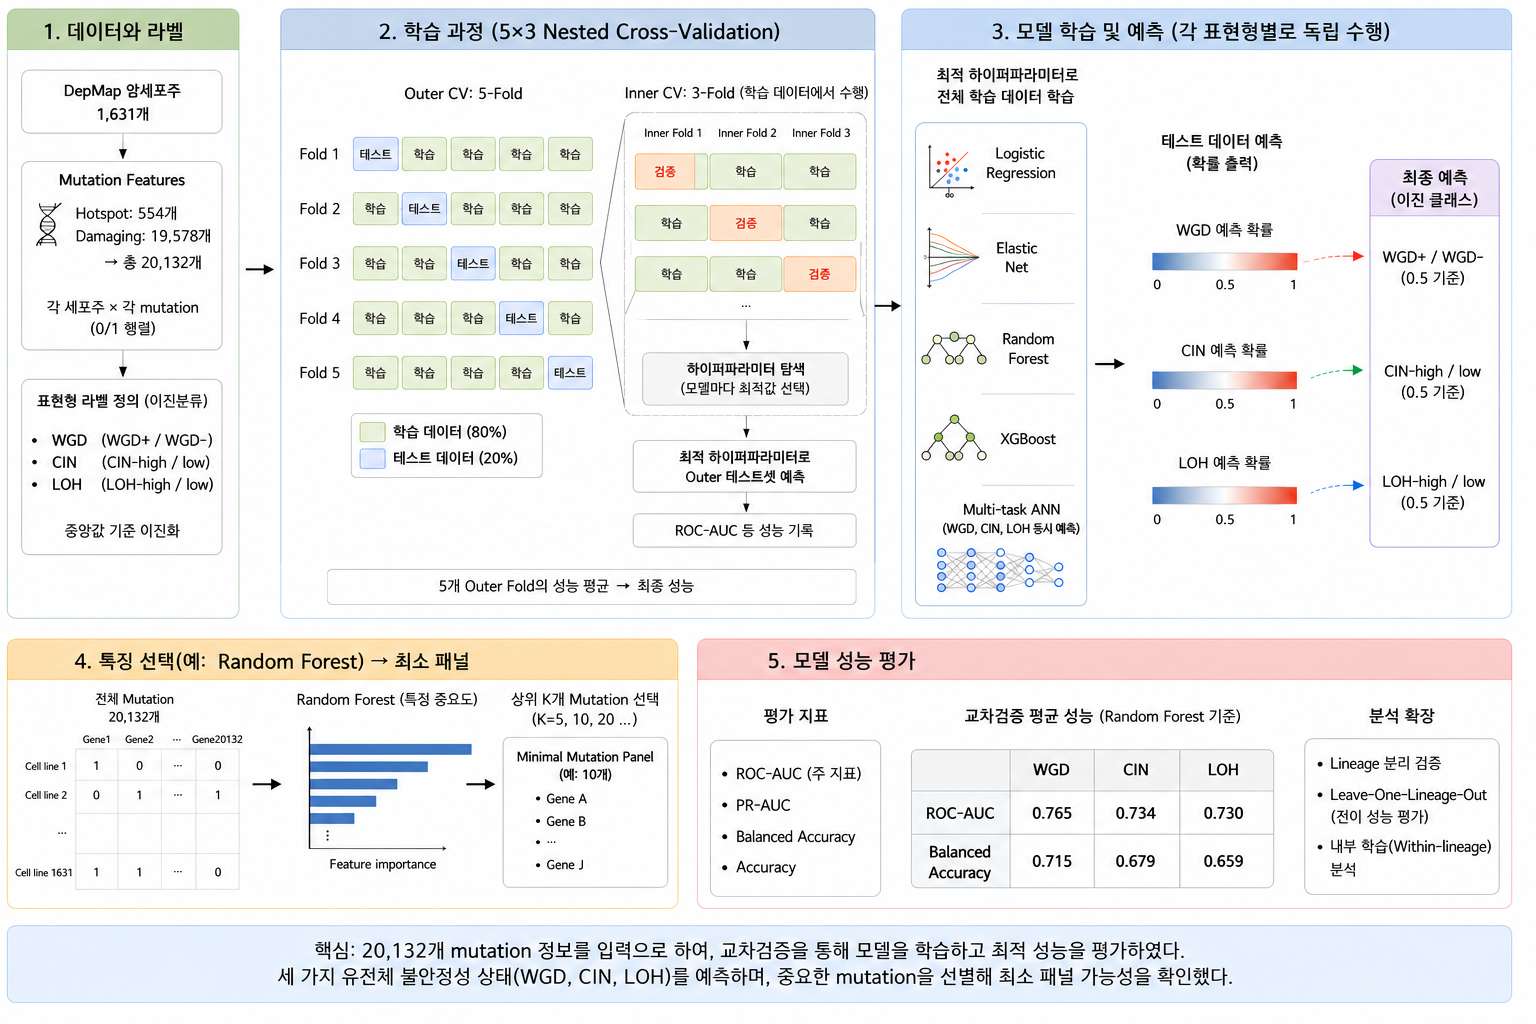

In [3]:
display(Image(filename=str(FIGURES / "fig1_overview.png")))

## 1. 데이터 로드 & 코호트 요약

DepMap 4개 원본 파일(hotspot/damaging mutation matrix, global signatures, model
metadata)을 ModelID 교집합으로 합치고 라벨 결측을 제거한다. 이 단계는 실제로
가볍게 실행된다(수 초).

In [4]:
# src/data/merge.py 의 load_cohort() 를 그대로 쓴다.
# 캐시(data/interim/cohort_*.parquet)가 있으면 읽고, 없으면 원본 CSV 에서 만들어 캐시에 저장한다.
from src.data.merge import load_cohort

cohort = load_cohort(verbose=True)
cohort_X, cohort_y, cohort_groups = cohort.X, cohort.y, cohort.groups
print(cohort.summary())
cohort_y.describe()

  캐시 사용: /home/kali/adni-shared/AI-bio-proj-team-1/data/interim
세포주 1,631 | feature 20,132 (hotspot 554 / damaging 19,578) | lineage 32종


,wgd,cin,loh
count,1631.000000,1631.000000,1631.000000
mean,0.652361,0.460105,0.210227
std,0.476367,0.246927,0.162156
min,0.000000,0.000000,0.000000
25%,0.000000,0.242061,0.073253
50%,1.000000,0.533116,0.187137
75%,1.000000,0.663973,0.318579
max,1.000000,0.859347,0.929901


데이터 원본 파일별 상세 통계는 `docs/depmap/input_data_summary.md`,
mutation matrix 병합 과정은 `docs/depmap/mutation_matrix.md`,
라벨(WGD/CIN/LoHFraction) 정의는 `docs/depmap/global_signatures.md` 참고.

## 2. EDA — mutation 빈도 / 표현형 분포

**Figure 2.** WGD/CIN/LOH 세 표현형의 분포. WGD는 이진(65.2%가 양성), CIN은
이봉형, LOH는 0 근처로 치우친 분포다.

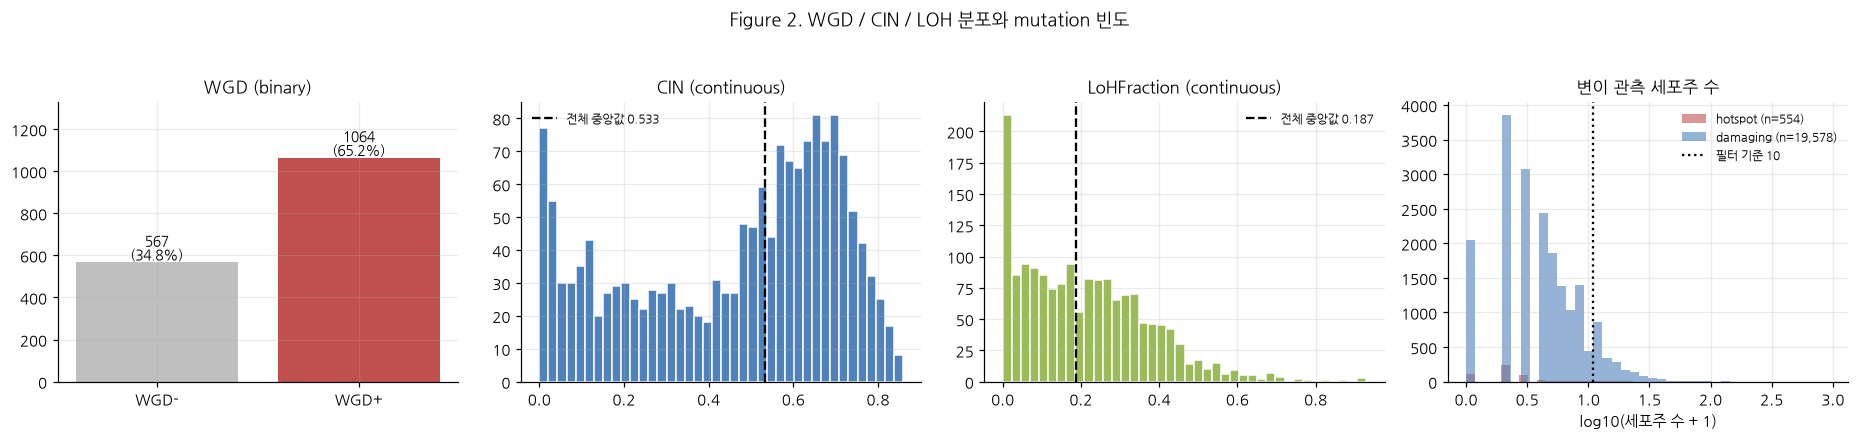

In [5]:
# Figure 2 — scripts/04_eda.py 의 plot_distributions() 를 그대로 옮긴 것.
freq = pd.DataFrame({
    "feature": cohort_X.columns,
    "kind": np.where(cohort_X.columns.str.endswith("_hotspot"), "hotspot", "damaging"),
    "n_cell_lines": (cohort_X > 0).sum(axis=0).to_numpy(),
})

fig, axes = plt.subplots(1, 4, figsize=(17, 3.8))

counts = cohort_y["wgd"].value_counts().sort_index()
axes[0].bar(["WGD-", "WGD+"], counts.to_numpy(), color=["#bfbfbf", PHENOTYPE_COLORS["wgd"]])
for i, v in enumerate(counts):
    axes[0].text(i, v, f"{v}\n({v / len(cohort_y):.1%})", ha="center", va="bottom", fontsize=9)
axes[0].set_title("WGD (binary)")
axes[0].set_ylim(0, counts.max() * 1.25)

for ax, name, label in ((axes[1], "cin", "CIN"), (axes[2], "loh", "LoHFraction")):
    ax.hist(cohort_y[name], bins=40, color=PHENOTYPE_COLORS[name], edgecolor="white")
    med = cohort_y[name].median()
    ax.axvline(med, color="k", ls="--", lw=1.5, label=f"전체 중앙값 {med:.3f}")
    ax.set_title(f"{label} (continuous)")
    ax.legend(fontsize=8)

for kind, color in (("hotspot", "#c0504d"), ("damaging", "#4f81bd")):
    sub = freq[freq.kind == kind].n_cell_lines
    axes[3].hist(np.log10(sub + 1), bins=40, alpha=0.6, label=f"{kind} (n={len(sub):,})", color=color)
axes[3].axvline(np.log10(11), color="k", ls=":", lw=1.5, label="필터 기준 10")
axes[3].set_title("변이 관측 세포주 수")
axes[3].set_xlabel("log10(세포주 수 + 1)")
axes[3].legend(fontsize=8)

fig.suptitle("Figure 2. WGD / CIN / LOH 분포와 mutation 빈도", y=1.04, fontsize=12)
fig.tight_layout()
plt.show()

## 3. 모델 비교 — 5개 모델 × 3표현형

Logistic Regression, Elastic Net, Random Forest, XGBoost, CatBoost를 동일한
nested cross-validation(outer 5-fold × inner 5-fold) 조건에서 비교했다. 희귀
변이 제거, CIN/LOH 이진화 threshold, hyperparameter, 분류 threshold는 모두 각
training fold 내부에서만 결정된다(outer test 데이터는 관여하지 않음, README §13).

재현: `python scripts/05_run_cv.py --model {model} --target {target}`
(model × target 조합마다), 집계는 `python scripts/06_compare_models.py`.

In [6]:
day10 = pd.read_csv(TABLES / "day10_model_comparison.csv")
day10_pivot = day10.pivot(index="model", columns="target", values="roc_auc")
day10_pivot = day10_pivot[["wgd", "cin", "loh"]].sort_values("wgd", ascending=False)
print("모델별 ROC-AUC (random 5-fold)")
day10_pivot.round(3)

모델별 ROC-AUC (random 5-fold)


target,wgd,cin,loh
model,,,
random_forest,0.765,0.734,0.730
catboost,0.762,0.711,0.717
xgboost,0.757,0.729,0.728
elastic_net,0.749,0.681,0.711
logistic,0.723,0.672,0.683
multitask_ann,0.704,0.671,0.667


### 3-1. 실제 학습 — nested CV 를 여기서 직접 돌린다

아래 두 셀은 `results/tables/*.csv` 를 읽어오는 것이 아니라, 위에서 불러온
mutation matrix로 **outer 5-fold / inner 5-fold nested CV 를 실제로 학습**한다.
`src/cv/nested.py`, `src/models/zoo.py` 의 구현을 이 노트북 안에 그대로 옮겨
두었으므로 저장소 코드 없이 단독 재현이 된다.

누출 방지(§13) 규칙도 그대로다 — 희귀변이 필터·CIN/LOH 이진화 threshold·
하이퍼파라미터·분류 threshold를 **전부 training fold 안에서만** 정하고,
outer test fold는 평가에만 쓴다.

In [7]:
# 학습에 쓰는 것들 — 전부 저장소 구현이다 (노트북에 사본 없음).
# 누출 방지(§13)는 run_nested_cv 안에서 처리된다:
#   희귀변이 필터·CIN/LOH 이진화 threshold·하이퍼파라미터·분류 threshold 를
#   모두 training fold 안에서만 정하고, outer test fold 는 평가에만 쓴다.
import time

from src.cv.nested import run_nested_cv
from src.cv.splitters import inner_cv, outer_splits
from src.evaluation.metrics import choose_threshold
from src.labels.binarize import LabelBinarizer
from src.models.zoo import get_model
from src.selection.aggregate import aggregate_selection

print("src 파이프라인 로드 완료 — 다음 셀에서 실제로 학습한다.")

src 파이프라인 로드 완료 — 다음 셀에서 실제로 학습한다.


In [8]:
# 실제 학습. 모델 1개 × 표현형 1개당 outer 5 × inner 5 = 25번 적합한다.
# 같은 학습에서 성능·feature 중요도(Figure 4)·test 예측(Figure 16)을 함께 받는다.
# RUN_MODELS 를 줄이면 더 빨리 끝나고, 늘리면 Figure 3 전체가 재현된다.
RUN_MODELS = ['logistic', 'elastic_net', 'random_forest', 'xgboost', 'catboost', 'multitask_ann']

_total = len(RUN_MODELS) * len(TARGETS)
print(f"nested CV {_total}개 조합 시작 "
      f"(Colab 무료 vCPU 2개 기준 조합당 수십 초~수 분)", flush=True)

live_rows, live_importances, live_predictions = [], {}, {}
_done, _t_all = 0, time.time()
for name in RUN_MODELS:
    spec = get_model(name)
    for target in TARGETS:
        _done += 1
        print(f"  [{_done}/{_total}] {name} / {TARGET_LABEL[target]} 학습 중...",
              end="", flush=True)
        t0 = time.time()
        res = run_nested_cv(cohort_X, cohort_y[target], cohort_groups, spec, target,
                            scheme="random", verbose=False)
        live_rows.append(res.metrics)
        live_importances[(name, target)] = res.importances
        live_predictions[(name, target)] = res.predictions
        print(f" ROC-AUC {res.metrics.roc_auc.mean():.3f} ({time.time() - t0:.0f}초)", flush=True)

cv_live = pd.concat(live_rows, ignore_index=True)
print(f"전체 {time.time() - _t_all:.0f}초", flush=True)
cv_live.groupby(["model", "target"]).roc_auc.mean().unstack().round(3)

nested CV 18개 조합 시작 (Colab 무료 vCPU 2개 기준 조합당 수십 초~수 분)


  [1/18] logistic / WGD 학습 중...

 ROC-AUC 0.723 (8초)


  [2/18] logistic / CIN 학습 중...

 ROC-AUC 0.672 (6초)


...

 ROC-AUC 0.671 (353초)


  [18/18] multitask_ann / LOH 학습 중...

 ROC-AUC 0.667 (359초)


전체 2859초


target,cin,loh,wgd
model,,,
catboost,0.711,0.717,0.762
elastic_net,0.681,0.711,0.749
logistic,0.672,0.683,0.723
multitask_ann,0.671,0.667,0.704
random_forest,0.734,0.730,0.765
xgboost,0.729,0.728,0.757


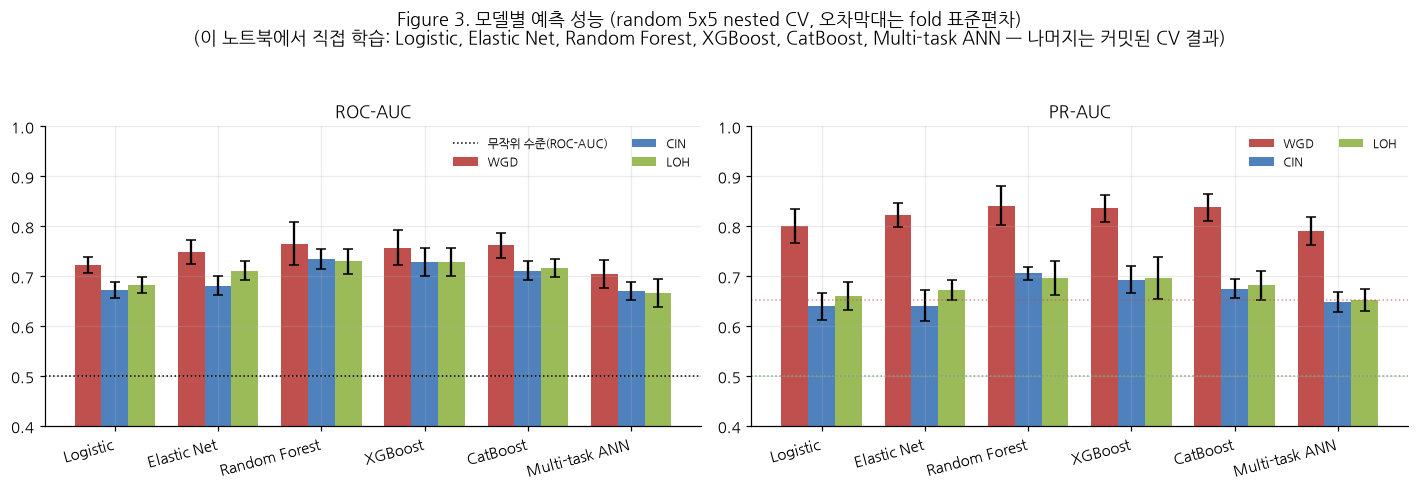

[이 노트북에서 학습한 모델의 평균 ROC-AUC]
target  model        
cin     catboost         0.711
        elastic_net      0.681
        logistic         0.672
        multitask_ann    0.671
        random_forest    0.734
        xgboost          0.729
loh     catboost         0.717
        elastic_net      0.711
        logistic         0.683
        multitask_ann    0.667
        random_forest    0.730
        xgboost          0.728
wgd     catboost         0.762
        elastic_net      0.749
        logistic         0.723
        multitask_ann    0.704
        random_forest    0.765
        xgboost          0.757


In [9]:
# Figure 3 — 위 셀에서 방금 학습한 결과(cv_live)로 그린다.
# RUN_MODELS 에 없는 모델은 저장소에 커밋된 results/tables/cv_random_*.csv 로 채운다.
MODEL_ORDER = ["logistic", "elastic_net", "random_forest", "xgboost", "catboost", "multitask_ann"]
MODEL_LABEL = {"logistic": "Logistic", "elastic_net": "Elastic Net",
               "random_forest": "Random Forest", "xgboost": "XGBoost",
               "catboost": "CatBoost", "multitask_ann": "Multi-task ANN"}

frames = [cv_live]
for m in MODEL_ORDER:
    if m in RUN_MODELS:
        continue
    for t in TARGETS:
        # glob 대신 정확한 파일명만 읽는다 — cv_random_random_forest_damaging_only_wgd.csv
        # (보조 파일)까지 섞이면 WGD/RF 행이 오염된다.
        path = TABLES / f"cv_random_{m}_{t}.csv"
        if path.exists():
            frames.append(pd.read_csv(path))
cv = pd.concat(frames, ignore_index=True)

# PR-AUC 의 무작위 기준선은 0.5 가 아니라 표현형별 양성 비율이다.
prevalence = {"wgd": float(cohort_y.wgd.mean())}
for t in ("cin", "loh"):
    prevalence[t] = float((cohort_y[t] >= cohort_y[t].median()).mean())

fig, axes = plt.subplots(1, 2, figsize=(13, 4.2))
models = [m for m in MODEL_ORDER if m in set(cv.model)]
width, x = 0.26, np.arange(len(models))

for ax, metric, title in ((axes[0], "roc_auc", "ROC-AUC"), (axes[1], "pr_auc", "PR-AUC")):
    for i, target in enumerate(TARGETS):
        sub = cv[cv.target == target]
        means = [sub[sub.model == m][metric].mean() for m in models]
        errs = [sub[sub.model == m][metric].std() for m in models]
        ax.bar(x + (i - 1) * width, means, width, yerr=errs, capsize=3,
               label=TARGET_LABEL[target], color=PHENOTYPE_COLORS[target])
    if metric == "roc_auc":
        ax.axhline(0.5, color="k", ls=":", lw=1, label="무작위 수준(ROC-AUC)")
    else:
        for target in TARGETS:
            ax.axhline(prevalence[target], color=PHENOTYPE_COLORS[target], ls=":", lw=1, alpha=0.6)
    ax.set_xticks(x)
    ax.set_xticklabels([MODEL_LABEL[m] for m in models], rotation=15, ha="right")
    ax.set_title(title)
    ax.set_ylim(0.4, 1.0)
    ax.legend(fontsize=8, ncol=2)

live = ", ".join(MODEL_LABEL[m] for m in RUN_MODELS)
fig.suptitle("Figure 3. 모델별 예측 성능 (random 5x5 nested CV, 오차막대는 fold 표준편차)\n"
             f"(이 노트북에서 직접 학습: {live} — 나머지는 커밋된 CV 결과)",
             y=1.05, fontsize=12)
fig.tight_layout()
plt.show()

print("[이 노트북에서 학습한 모델의 평균 ROC-AUC]")
print(cv_live.groupby(["target", "model"]).roc_auc.mean().round(3).to_string())

**Random Forest가 세 표현형 모두에서 1위**다(WGD 0.765 / CIN 0.734 / LOH 0.730).
비선형 모델(RF/XGBoost/CatBoost, 평균 0.73\~0.74)이 선형 모델(평균 0.69\~0.71)을
일관되게 앞서지만 그 차이는 0.05 내외다.

## 4. Random Forest confusion matrix (최고 성능 모델)

5개 outer fold의 test 예측을 모두 모아(pooled) 하나의 confusion matrix로
합쳤다. Threshold는 각 fold의 training 데이터 안에서 out-of-fold 예측으로만
결정했다(§13).

재현: `python scripts/33_rf_confusion_matrix.py`, `python scripts/34_plot_rf_confusion_matrix.py`.

In [10]:
cm = pd.read_csv(TABLES / "day33_rf_confusion_matrix.csv")
cm

,target,tn,fp,fn,tp,n,sensitivity,specificity,balanced_accuracy
0,wgd,384,183,264,800,1631,0.751880,0.677249,0.714564
1,cin,538,277,248,568,1631,0.696078,0.660123,0.678101
2,loh,494,321,207,609,1631,0.746324,0.606135,0.676229


§3-1 에서 학습한 Random Forest 의 outer fold 예측을 pool 했다 (추가 학습 없음).


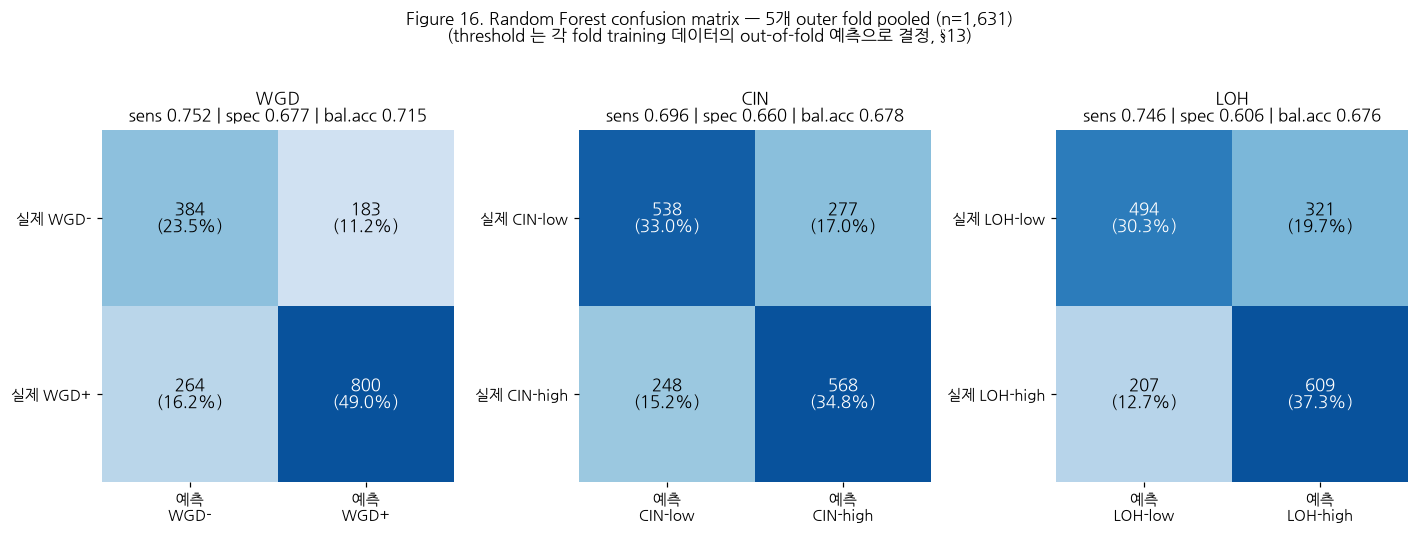

In [11]:
# Figure 16 — §3-1 학습이 남긴 outer test 예측을 모아서(pool) 만든다.
# 예전에는 여기서 Random Forest 를 다시 학습했는데(표현형당 130회 적합),
# §3-1 과 완전히 같은 계산이라 중복이었다. run_nested_cv 가 예측을 돌려주므로
# 이제 추가 학습이 없다.
from sklearn.metrics import confusion_matrix

CLASS_LABEL = {"wgd": ("WGD-", "WGD+"), "cin": ("CIN-low", "CIN-high"),
               "loh": ("LOH-low", "LOH-high")}

if ("random_forest", "wgd") in live_predictions:
    cm_rows = []
    for _t in TARGETS:
        p = live_predictions[("random_forest", _t)]
        tn, fp, fn, tp = confusion_matrix(p.y_true, p.y_pred, labels=[0, 1]).ravel()
        sens, spec_ = tp / (tp + fn), tn / (tn + fp)
        cm_rows.append({"target": _t, "tn": tn, "fp": fp, "fn": fn, "tp": tp,
                        "n": len(p), "sensitivity": sens, "specificity": spec_,
                        "balanced_accuracy": (sens + spec_) / 2})
    cm_df = pd.DataFrame(cm_rows).set_index("target")
    print("§3-1 에서 학습한 Random Forest 의 outer fold 예측을 pool 했다 (추가 학습 없음).")
else:
    cm_df = pd.read_csv(TABLES / "day33_rf_confusion_matrix.csv").set_index("target")
    print("RUN_MODELS 에 random_forest 가 없어 커밋된 결과를 사용한다.")

fig, axes = plt.subplots(1, 3, figsize=(13, 4.4))
for ax, target in zip(axes, TARGETS):
    row = cm_df.loc[target]
    cm = np.array([[row.tn, row.fp], [row.fn, row.tp]])
    cm_pct = cm / cm.sum() * 100
    ax.imshow(cm_pct, cmap="Blues", vmin=0, vmax=cm_pct.max() * 1.15)
    labels = CLASS_LABEL[target]
    for i in range(2):
        for j in range(2):
            color = "white" if cm_pct[i, j] > cm_pct.max() * 0.6 else "black"
            ax.text(j, i, f"{int(cm[i, j])}\n({cm_pct[i, j]:.1f}%)",
                    ha="center", va="center", fontsize=11, color=color)
    ax.set_xticks([0, 1]); ax.set_xticklabels([f"예측\n{labels[0]}", f"예측\n{labels[1]}"])
    ax.set_yticks([0, 1]); ax.set_yticklabels([f"실제 {labels[0]}", f"실제 {labels[1]}"])
    ax.set_title(f"{TARGET_LABEL[target]}\nsens {row.sensitivity:.3f} | "
                 f"spec {row.specificity:.3f} | bal.acc {row.balanced_accuracy:.3f}")
    for sp in ax.spines.values():
        sp.set_visible(False)
    ax.grid(False)

fig.suptitle("Figure 16. Random Forest confusion matrix — 5개 outer fold pooled (n=1,631)\n"
             "(threshold 는 각 fold training 데이터의 out-of-fold 예측으로 결정, §13)",
             y=1.06, fontsize=11)
fig.tight_layout()
plt.show()

## 5. 반복 Feature Selection — 어떤 mutation이 중요한가

각 outer fold의 training data에서 feature selection을 반복해, 5개 fold 모두에서
선택된("전 fold 공통") 유전자를 찾는다. Elastic Net과 Random Forest 두 모델
기준으로 각각 뽑았다.

재현: `python scripts/07_aggregate_selection.py --model {elastic_net,random_forest}`.

In [12]:
for model in ("elastic_net", "random_forest"):
    print(f"=== {model} ===")
    for target in ("wgd", "cin", "loh"):
        df = pd.read_csv(TABLES / f"day11_selection_{model}_{target}.csv")
        common = df[df.selection_freq == 1.0]
        genes = ", ".join(common.gene.head(8))
        print(f"  {target.upper()}: 전 fold(5/5) 공통 {len(common)}개 — {genes}")
    print()

=== elastic_net ===
  WGD: 전 fold(5/5) 공통 12개 — TP53, BRAF, ID3, TERT, TP53, CREBBP, LRP1B, CCND3
  CIN: 전 fold(5/5) 공통 5개 — TP53, ID3, BRAF, TERT, RB1
  LOH: 전 fold(5/5) 공통 9개 — TP53, NF2, ID3, PITX1, RB1, BRAF, CREBBP, MUC19

=== random_forest ===
  WGD: 전 fold(5/5) 공통 19개 — TP53, TP53, TERT, BRAF, ID3, LRP1B, TTN, KRAS
  CIN: 전 fold(5/5) 공통 21개 — TP53, TP53, TERT, RB1, ID3, BRAF, PIK3CA, KRAS
  LOH: 전 fold(5/5) 공통 18개 — TP53, TP53, RB1, ID3, KRAS, NF2, ARID1A, PITX1



§3-1 학습에서 fold 별로 기록한 중요도를 집계했다.


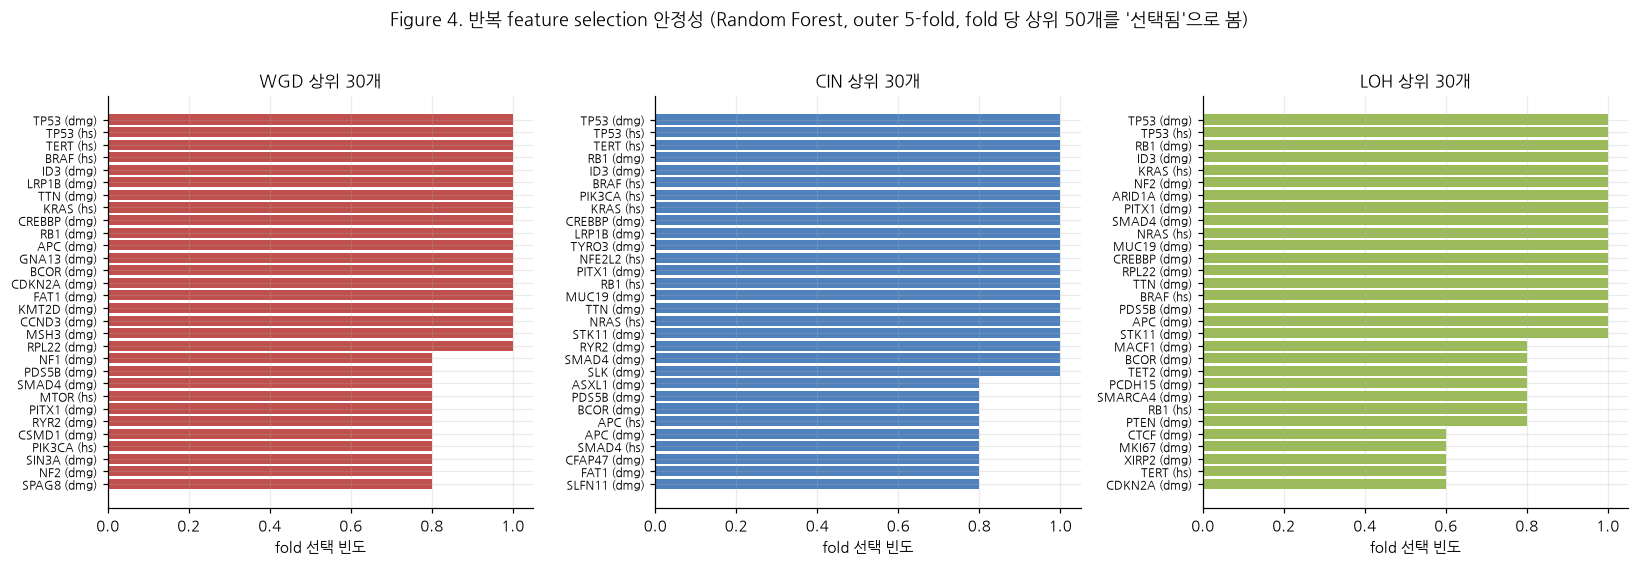

  WGD: 전 fold 선택 19개 — TP53 (dmg), TP53 (hs), TERT (hs), BRAF (hs), ID3 (dmg), LRP1B (dmg), TTN (dmg), KRAS (hs)
  CIN: 전 fold 선택 21개 — TP53 (dmg), TP53 (hs), TERT (hs), RB1 (dmg), ID3 (dmg), BRAF (hs), PIK3CA (hs), KRAS (hs)
  LOH: 전 fold 선택 18개 — TP53 (dmg), TP53 (hs), RB1 (dmg), ID3 (dmg), KRAS (hs), NF2 (dmg), ARID1A (dmg), PITX1 (dmg)


In [13]:
# Figure 4 — §3-1 학습이 fold 마다 기록한 중요도를 src 의 aggregate_selection 으로 집계한다.
TOP_N, TOP_K = 30, 50


def short(feature, width=22):
    """'TP53 (7157)_damaging' -> 'TP53 (dmg)'"""
    gene = feature.split(" (")[0]
    kind = "hs" if feature.endswith("_hotspot") else "dmg"
    return f"{gene} ({kind})"[:width]


_key = ("random_forest", "wgd")
if _key in live_importances and not live_importances[_key].empty:
    aggs = {t: aggregate_selection(live_importances[("random_forest", t)], top_k=TOP_K)
            for t in TARGETS}
    print("§3-1 학습에서 fold 별로 기록한 중요도를 집계했다.")
else:
    aggs = {t: pd.read_csv(TABLES / f"day11_selection_random_forest_{t}.csv") for t in TARGETS}
    print("RUN_MODELS 에 random_forest 가 없어 커밋된 결과를 사용한다.")

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
for ax, target in zip(axes, TARGETS):
    top = aggs[target].head(TOP_N).iloc[::-1]
    ax.barh([short(f) for f in top.feature], top.selection_freq, color=PHENOTYPE_COLORS[target])
    ax.set_xlim(0, 1.05)
    ax.set_xlabel("fold 선택 빈도")
    ax.set_title(f"{TARGET_LABEL[target]} 상위 {TOP_N}개")
    ax.tick_params(axis="y", labelsize=8)

fig.suptitle(f"Figure 4. 반복 feature selection 안정성 (Random Forest, outer 5-fold, "
             f"fold 당 상위 {TOP_K}개를 '선택됨'으로 봄)", y=1.02, fontsize=12)
fig.tight_layout()
plt.show()

for t in TARGETS:
    stable = aggs[t][aggs[t].selection_freq == 1.0]
    print(f"  {TARGET_LABEL[t]}: 전 fold 선택 {len(stable)}개 — "
          + ", ".join(short(f) for f in stable.feature.head(8)))

## 6. 최소 mutation panel — 몇 개까지 줄여도 되는가

5/10/20/50개로 축소한 패널이 전체 feature 대비 성능을 얼마나 유지하는지,
그리고 fold 간 패널 구성의 안정성(Jaccard 유사도)을 본다.

재현: `python scripts/08_panel_curve.py --model {elastic_net,random_forest}`.

In [14]:
panel = pd.read_csv(TABLES / "day12_panel_metrics_random_forest.csv")
panel_pivot = panel.pivot_table(index="target", columns="panel_size", values="roc_auc", aggfunc="mean")
panel_pivot = panel_pivot.reindex(columns=["5", "10", "20", "50", "all"])
print("Random Forest — 패널 크기별 ROC-AUC")
panel_pivot.round(3)

Random Forest — 패널 크기별 ROC-AUC


panel_size,5,10,20,50,all
target,,,,,
cin,0.671,0.682,0.699,0.718,0.734
loh,0.666,0.687,0.709,0.715,0.730
wgd,0.723,0.729,0.740,0.751,0.765


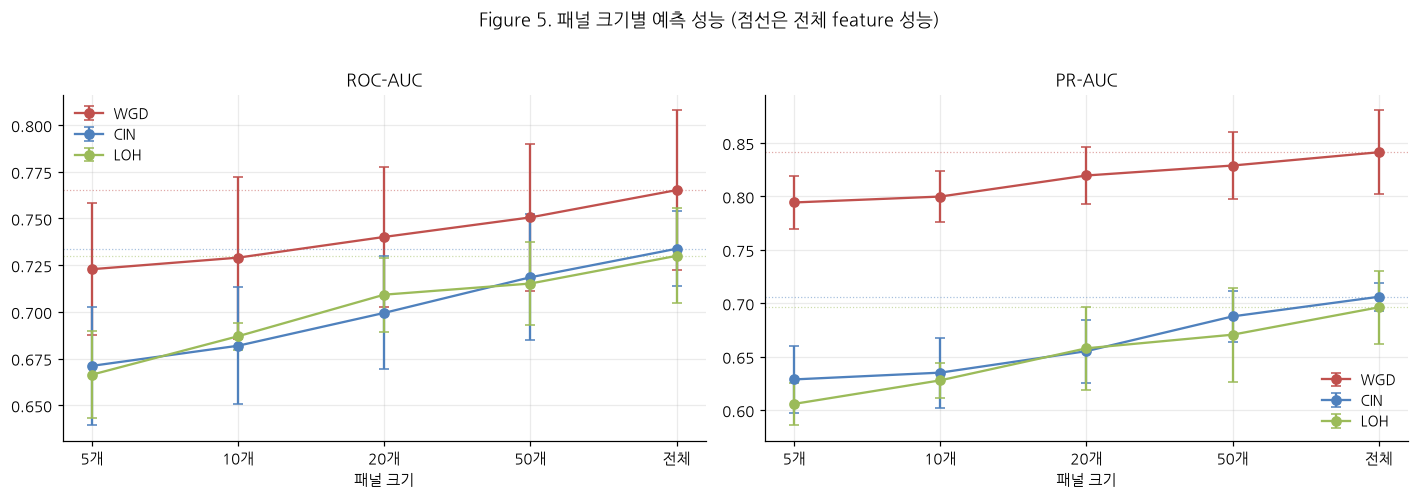

In [15]:
# Figure 5 — scripts/08_panel_curve.py 의 plot_curve() 를 그대로 옮긴 것.
metrics = pd.read_csv(TABLES / "day12_panel_metrics_random_forest.csv")
metrics["panel_size"] = metrics["panel_size"].astype(str)
sizes = sorted({int(s) for s in metrics.panel_size.unique() if s != "all"})
order = [str(s) for s in sizes] + ["all"]

fig, axes = plt.subplots(1, 2, figsize=(13, 4.4))
for ax, metric, title in ((axes[0], "roc_auc", "ROC-AUC"), (axes[1], "pr_auc", "PR-AUC")):
    for target in TARGETS:
        sub = metrics[metrics.target == target]
        g = sub.groupby("panel_size")[metric]
        mean, std = g.mean().reindex(order), g.std().reindex(order)
        ax.errorbar(range(len(order)), mean, yerr=std, marker="o", capsize=3,
                    label=TARGET_LABEL[target], color=PHENOTYPE_COLORS[target])
        full = mean.get("all")
        if pd.notna(full):
            ax.axhline(full, color=PHENOTYPE_COLORS[target], ls=":", lw=0.8, alpha=0.5)
    ax.set_xticks(range(len(order)))
    ax.set_xticklabels([f"{o}개" if o != "all" else "전체" for o in order])
    ax.set_xlabel("패널 크기")
    ax.set_title(title)
    ax.legend(fontsize=9)

fig.suptitle("Figure 5. 패널 크기별 예측 성능 (점선은 전체 feature 성능)", y=1.02, fontsize=12)
fig.tight_layout()
plt.show()

**10개 패널로 전체 성능의 93\~99%가 유지된다.** 다만 fold마다 어떤 유전자가
뽑히는지는 달라진다(Jaccard 유사도 <1) — `day12_panel_stability_random_forest.csv`
참고. 자세한 해석은 `docs/research/2026-08-16/final_conclusion.md` §26④,
"Day 11/12 Random Forest 재검증" 절 참고.

## 7. Lineage(암종) 일반화 — GroupKFold / Leave-One-Lineage-Out

같은 lineage(암종)의 세포주가 train/test에 섞이지 않도록 분리하면 성능이
어떻게 달라지는지 본다.

재현: `python scripts/09_lineage_validation.py --model {elastic_net,random_forest}`,
`python scripts/11_lineage_specific.py`,
`python scripts/15_lineage_hypothesis_test.py`.

In [16]:
lineage_cmp = pd.read_csv(TABLES / "day13_lineage_comparison_random_forest.csv")
lineage_cmp

,target,group,random,차이
0,cin,0.677864,0.733763,-0.055899
1,loh,0.683452,0.729966,-0.046514
2,wgd,0.700460,0.765161,-0.064701


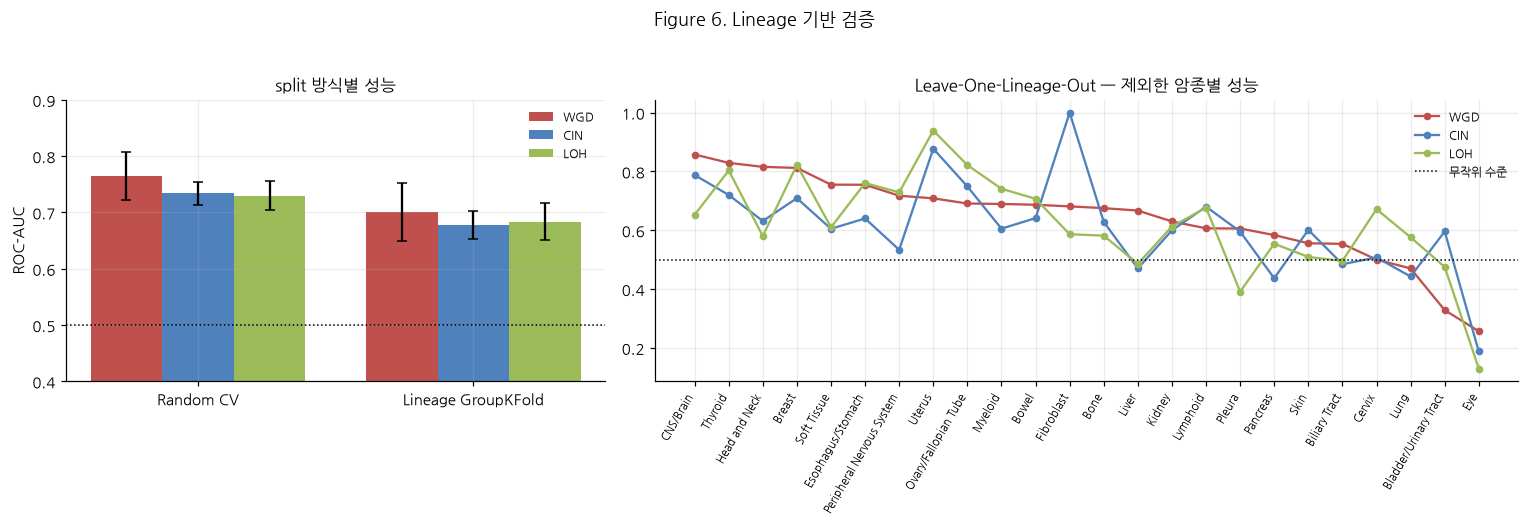

In [17]:
# Figure 6 — scripts/09_lineage_validation.py 의 plot_lineage_comparison() 을 그대로 옮긴 것.
rand = pd.concat([pd.read_csv(TABLES / f"cv_random_random_forest_{t}.csv") for t in TARGETS],
                 ignore_index=True)
group = pd.concat([pd.read_csv(TABLES / f"cv_group_random_forest_{t}.csv") for t in TARGETS],
                  ignore_index=True)
lolo = pd.concat([pd.read_csv(TABLES / f"cv_lolo_random_forest_{t}.csv") for t in TARGETS],
                 ignore_index=True)
combined = pd.concat([rand, group], ignore_index=True)

fig, axes = plt.subplots(1, 2, figsize=(14, 4.6), gridspec_kw={"width_ratios": [1, 1.6]})
schemes = ["random", "group"]
width, x = 0.26, np.arange(len(schemes))
for i, target in enumerate(TARGETS):
    means = [combined[(combined.target == target) & (combined.scheme == s)].roc_auc.mean() for s in schemes]
    errs = [combined[(combined.target == target) & (combined.scheme == s)].roc_auc.std() for s in schemes]
    axes[0].bar(x + (i - 1) * width, means, width, yerr=errs, capsize=3,
                label=TARGET_LABEL[target], color=PHENOTYPE_COLORS[target])
axes[0].axhline(0.5, color="k", ls=":", lw=1)
axes[0].set_xticks(x)
axes[0].set_xticklabels(["Random CV", "Lineage GroupKFold"])
axes[0].set_ylabel("ROC-AUC")
axes[0].set_ylim(0.4, 0.9)
axes[0].set_title("split 방식별 성능")
axes[0].legend(fontsize=8)

order = (lolo[lolo.target == "wgd"].sort_values("roc_auc", ascending=False)
         .held_out_lineage.tolist())
for target in TARGETS:
    sub = lolo[lolo.target == target].set_index("held_out_lineage").reindex(order)
    axes[1].plot(range(len(order)), sub.roc_auc, marker="o", ms=4,
                 label=TARGET_LABEL[target], color=PHENOTYPE_COLORS[target])
axes[1].axhline(0.5, color="k", ls=":", lw=1, label="무작위 수준")
axes[1].set_xticks(range(len(order)))
axes[1].set_xticklabels(order, rotation=60, ha="right", fontsize=7)
axes[1].set_title("Leave-One-Lineage-Out — 제외한 암종별 성능")
axes[1].legend(fontsize=8)

fig.suptitle("Figure 6. Lineage 기반 검증", y=1.03, fontsize=12)
fig.tight_layout()
plt.show()

Leave-One-Lineage-Out(LOLO)에서는 암종별 성능 편차가 훨씬 크다(WGD 기준
0.314\~0.882). 왜 어떤 암종에서는 신호가 있고 어떤 암종에서는 없는지 다섯 개
가설(기저율, 표본 크기, TP53 변이율, mutation burden, TP53 변이율의 극단성)로
검정했으나 모두 기각됐다 — 단순 단변량 교란변수로는 설명되지 않는다.

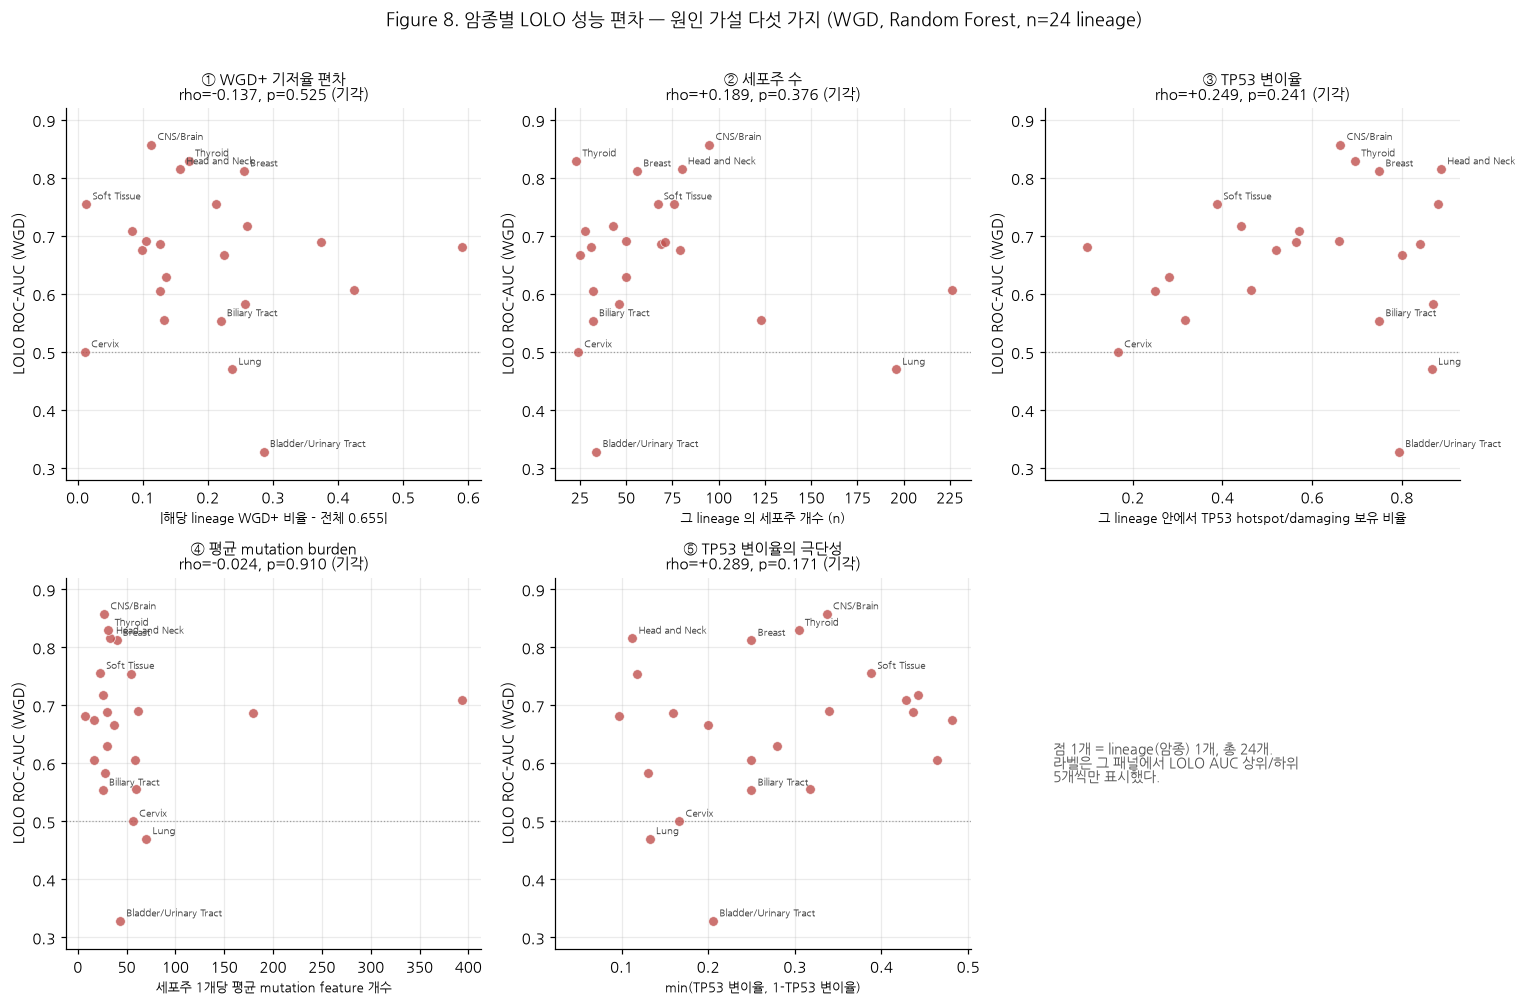

  ① WGD+ 기저율 편차          rho=-0.137 p=0.525
  ② 세포주 수                rho=+0.189 p=0.376
  ③ TP53 변이율             rho=+0.249 p=0.241
  ④ 평균 mutation burden   rho=-0.024 p=0.910
  ⑤ TP53 변이율의 극단성        rho=+0.289 p=0.171


In [18]:
# Figure 8 — scripts/16_plot_lineage_hypotheses.py 를 그대로 옮긴 것 (WGD, Random Forest).
from scipy.stats import spearmanr

TGT = "wgd"
lolo_w = pd.read_csv(TABLES / f"cv_lolo_random_forest_{TGT}.csv")[
    ["held_out_lineage", "roc_auc", "n_test", "positive_rate"]
].rename(columns={"held_out_lineage": "lineage", "n_test": "n"})
global_rate = (lolo_w.positive_rate * lolo_w.n).sum() / lolo_w.n.sum()
lolo_w["base_rate_dev"] = (lolo_w.positive_rate - global_rate).abs()
extra = pd.read_csv(TABLES / f"day15_lineage_hypothesis_features_random_forest_{TGT}.csv")[
    ["lineage", "tp53_rate", "mean_burden", "tp53_extremity"]
]
hyp = lolo_w.merge(extra, on="lineage")


def panel(ax, df, x_col, title, xlabel, n_label=5):
    r = spearmanr(df[x_col], df.roc_auc)
    ax.scatter(df[x_col], df.roc_auc, s=40, color=PHENOTYPE_COLORS[TGT], alpha=0.8,
               edgecolor="white", linewidth=0.5, zorder=3)
    ax.axhline(0.5, color="#999", ls=":", lw=0.8, zorder=1)
    ranked = df.sort_values("roc_auc")
    for _, row in pd.concat([ranked.head(n_label), ranked.tail(n_label)]).drop_duplicates("lineage").iterrows():
        ax.annotate(row.lineage, (row[x_col], row.roc_auc), fontsize=6.5,
                    xytext=(4, 3), textcoords="offset points", color="#444")
    verdict = "기각" if r.pvalue >= 0.05 else "유의"
    ax.set_title(f"{title}\nrho={r.statistic:+.3f}, p={r.pvalue:.3f} ({verdict})", fontsize=9.5)
    ax.set_xlabel(xlabel, fontsize=8.5)
    ax.set_ylabel("LOLO ROC-AUC (WGD)")
    ax.set_ylim(0.28, 0.92)


fig, axes = plt.subplots(2, 3, figsize=(14, 9))
specs = [
    ("base_rate_dev", "① WGD+ 기저율 편차", f"|해당 lineage WGD+ 비율 - 전체 {global_rate:.3f}|"),
    ("n", "② 세포주 수", "그 lineage 의 세포주 개수 (n)"),
    ("tp53_rate", "③ TP53 변이율", "그 lineage 안에서 TP53 hotspot/damaging 보유 비율"),
    ("mean_burden", "④ 평균 mutation burden", "세포주 1개당 평균 mutation feature 개수"),
    ("tp53_extremity", "⑤ TP53 변이율의 극단성", "min(TP53 변이율, 1-TP53 변이율)"),
]
for ax, (col, title, xlabel) in zip(axes.flat, specs):
    panel(ax, hyp, col, title, xlabel)
axes.flat[-1].axis("off")
axes.flat[-1].text(0.02, 0.5,
                   "점 1개 = lineage(암종) 1개, 총 24개.\n"
                   "라벨은 그 패널에서 LOLO AUC 상위/하위\n"
                   "5개씩만 표시했다.",
                   fontsize=9, color="#555", va="center", transform=axes.flat[-1].transAxes)

fig.suptitle("Figure 8. 암종별 LOLO 성능 편차 — 원인 가설 다섯 가지 "
             "(WGD, Random Forest, n=24 lineage)", y=1.01, fontsize=12)
fig.tight_layout()
plt.show()

for col, title, _ in specs:
    r = spearmanr(hyp[col], hyp.roc_auc)
    print(f"  {title:22s} rho={r.statistic:+.3f} p={r.pvalue:.3f}")

## 8. CIN/LOH 이진화가 정보를 버리는가 — 회귀로 직접 검증

CIN/LoHFraction을 중앙값으로 잘라 분류하는 대신, 같은 mutation feature로 연속값을
직접 회귀 예측해 분류 ROC-AUC와 비교한다.

재현: `python scripts/17_regression_vs_classification.py`.

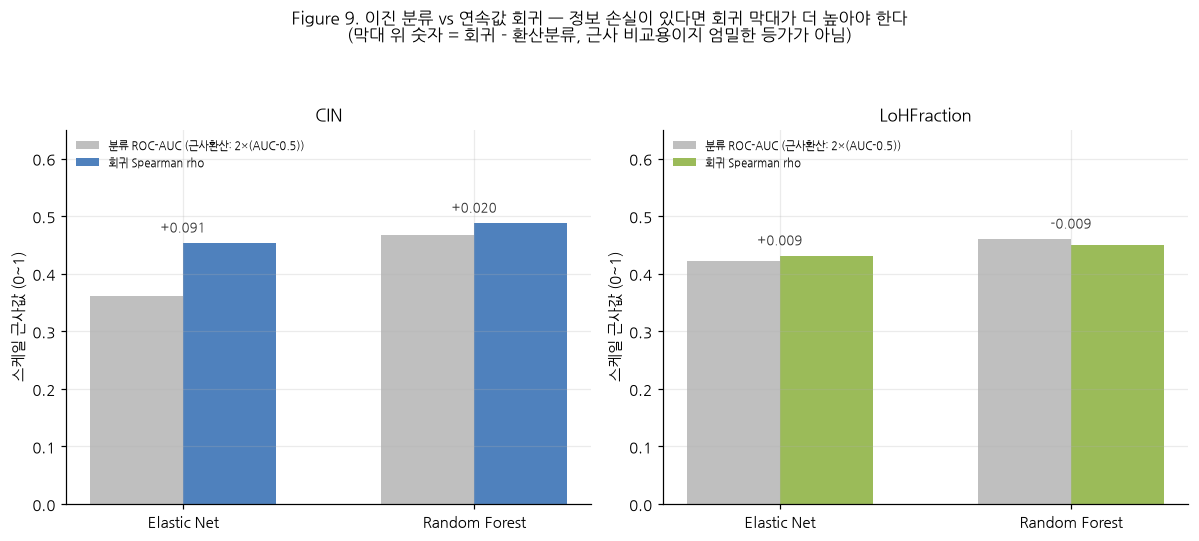

target  model_family  clf_roc_auc  reg_spearman_rho     차이  clf_auc_as_rho
   cin   elastic_net        0.681             0.453  0.091           0.362
   loh   elastic_net        0.711             0.431  0.009           0.422
   cin random_forest        0.734             0.488  0.020           0.468
   loh random_forest        0.730             0.451 -0.009           0.460


In [19]:
# Figure 9 — scripts/18_plot_regression_vs_classification.py 를 그대로 옮긴 것.
cmp_df = pd.read_csv(TABLES / "day15b_regression_vs_classification.csv")
cmp_df["clf_auc_as_rho"] = (cmp_df.clf_roc_auc - 0.5) * 2
families = ["elastic_net", "random_forest"]
family_label = {"elastic_net": "Elastic Net", "random_forest": "Random Forest"}
REG_LABEL = {"cin": "CIN", "loh": "LoHFraction"}

fig, axes = plt.subplots(1, 2, figsize=(11, 4.6))
for ax, target in zip(axes, ("cin", "loh")):
    sub = cmp_df[cmp_df.target == target].set_index("model_family").reindex(families)
    x, width = np.arange(len(families)), 0.32
    ax.bar(x - width / 2, sub.clf_auc_as_rho, width,
           label="분류 ROC-AUC (근사환산: 2×(AUC-0.5))", color="#bfbfbf")
    ax.bar(x + width / 2, sub.reg_spearman_rho, width,
           label="회귀 Spearman rho", color=PHENOTYPE_COLORS[target])
    for i, (auc_rho, reg_rho) in enumerate(zip(sub.clf_auc_as_rho, sub.reg_spearman_rho)):
        ax.text(i, max(auc_rho, reg_rho) + 0.02, f"{reg_rho - auc_rho:+.3f}",
                ha="center", fontsize=8.5, color="#333")
    ax.set_xticks(x)
    ax.set_xticklabels([family_label[f] for f in families])
    ax.set_ylim(0, 0.65)
    ax.set_ylabel("스케일 근사값 (0~1)")
    ax.set_title(REG_LABEL[target])
    ax.legend(fontsize=7.5, loc="upper left")

fig.suptitle("Figure 9. 이진 분류 vs 연속값 회귀 — 정보 손실이 있다면 회귀 막대가 더 높아야 한다\n"
             "(막대 위 숫자 = 회귀 - 환산분류, 근사 비교용이지 엄밀한 등가가 아님)",
             y=1.06, fontsize=11)
fig.tight_layout()
plt.show()
print(cmp_df.round(3).to_string(index=False))

Random Forest는 CIN·LOH 어느 쪽도 이진화로 정보를 거의 잃지 않는다. **CIN을
Elastic Net(선형 모델)으로 볼 때만** 이진화가 신호를 깎아 먹는다(+0.091). 이
결과의 CIN 패널 재검증은 §11 참고.

## 9. Pathway 단위 재집계 — 실행 결과 (음성)

20,132개 유전자 컬럼을 MSigDB Hallmark 5개 + KEGG DNA repair 6개, 총 11개
gene set으로 재집계했을 때 성능이 어떻게 달라지는지 본다.

재현: `python scripts/19_pathway_representation.py`.

In [20]:
pathway = pd.read_csv(TABLES / "day19_pathway_vs_gene.csv")
pathway

,target,model,gene_level_auc,pathway_auc,차이
0,wgd,logistic,0.723,0.673775,-0.049225
1,cin,logistic,0.672,0.643151,-0.028849
2,loh,logistic,0.683,0.647836,-0.035164
3,wgd,random_forest,0.765,0.720302,-0.044698
4,cin,random_forest,0.734,0.691052,-0.042948
5,loh,random_forest,0.730,0.701923,-0.028077


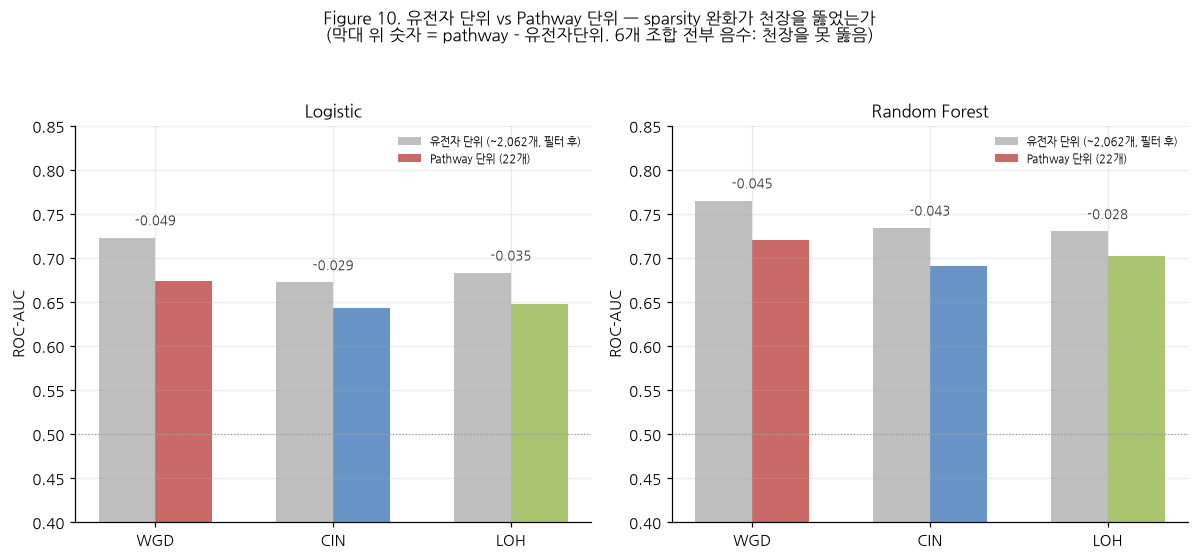

target         model  gene_level_auc  pathway_auc     차이
   wgd      logistic           0.723        0.674 -0.049
   cin      logistic           0.672        0.643 -0.029
   loh      logistic           0.683        0.648 -0.035
   wgd random_forest           0.765        0.720 -0.045
   cin random_forest           0.734        0.691 -0.043
   loh random_forest           0.730        0.702 -0.028


In [21]:
# Figure 10 — scripts 의 해당 plot 스크립트를 그대로 옮긴 것.
df = pd.read_csv(TABLES / "day19_pathway_vs_gene.csv")
models = ["logistic", "random_forest"]
MODEL_LABEL2 = {"logistic": "Logistic", "random_forest": "Random Forest"}

fig, axes = plt.subplots(1, 2, figsize=(11, 4.8))
for ax, model in zip(axes, models):
    sub = df[df.model == model].set_index("target").reindex(list(TARGETS))
    x, width = np.arange(3), 0.32
    ax.bar(x - width / 2, sub.gene_level_auc, width,
           label="유전자 단위 (~2,062개, 필터 후)", color="#bfbfbf")
    ax.bar(x + width / 2, sub.pathway_auc, width,
           label="Pathway 단위 (22개)", color=[PHENOTYPE_COLORS[t] for t in TARGETS], alpha=0.85)
    for i, (gene_auc, other) in enumerate(zip(sub.gene_level_auc, sub.pathway_auc)):
        ax.text(i, max(gene_auc, other) + 0.015, f"{other - gene_auc:+.3f}",
                ha="center", fontsize=8.5, color="#333")
    ax.axhline(0.5, color="#999", ls=":", lw=0.8)
    ax.set_xticks(x)
    ax.set_xticklabels([TARGET_LABEL[t] for t in TARGETS])
    ax.set_ylim(0.4, 0.85)
    ax.set_ylabel("ROC-AUC")
    ax.set_title(MODEL_LABEL2[model])
    ax.legend(fontsize=7.5, loc="upper right")

fig.suptitle("Figure 10. 유전자 단위 vs Pathway 단위 — sparsity 완화가 천장을 뚫었는가\n"
             "(막대 위 숫자 = pathway - 유전자단위. 6개 조합 전부 음수: 천장을 못 뚫음)", y=1.05, fontsize=11)
fig.tight_layout()
plt.show()
print(df.round(3).to_string(index=False))

**6개 조합(2모델×3표현형) 전부 pathway 쪽이 낮다(-0.028\~-0.049).** "sparsity를
줄이면 성능이 오른다"는 가설은 기각됐다 — 핵심 신호가 TP53 같은 소수 유전자에
집중돼 있어서, pathway로 뭉뚱그리면 오히려 정보가 희석된다.

## 10. Mutation Signature(96-class) 표현 — 실행 결과 (양성)

DepMap이 별도 배포하는 원시 MAF에서 trinucleotide context를 계산해, COSMIC SBS
표준 96-class 치환 비율을 세포주별 feature로 썼다 — pathway와 정반대로,
**유전자 정체성이 아니라 "어떤 변이 발생 과정이었는가"라는 다른 축의 정보**다.

재현: `python scripts/23_build_mutation_signature.py`,
`python scripts/24_signature_representation.py`.

In [22]:
sig = pd.read_csv(TABLES / "day24_signature_vs_gene.csv")
sig

,target,model,gene_level_auc,signature_auc,차이
0,wgd,logistic,0.723,0.713479,-0.009521
1,cin,logistic,0.672,0.710571,0.038571
2,loh,logistic,0.683,0.693428,0.010428
3,wgd,random_forest,0.765,0.770477,0.005477
4,cin,random_forest,0.734,0.761834,0.027834
5,loh,random_forest,0.730,0.742923,0.012923


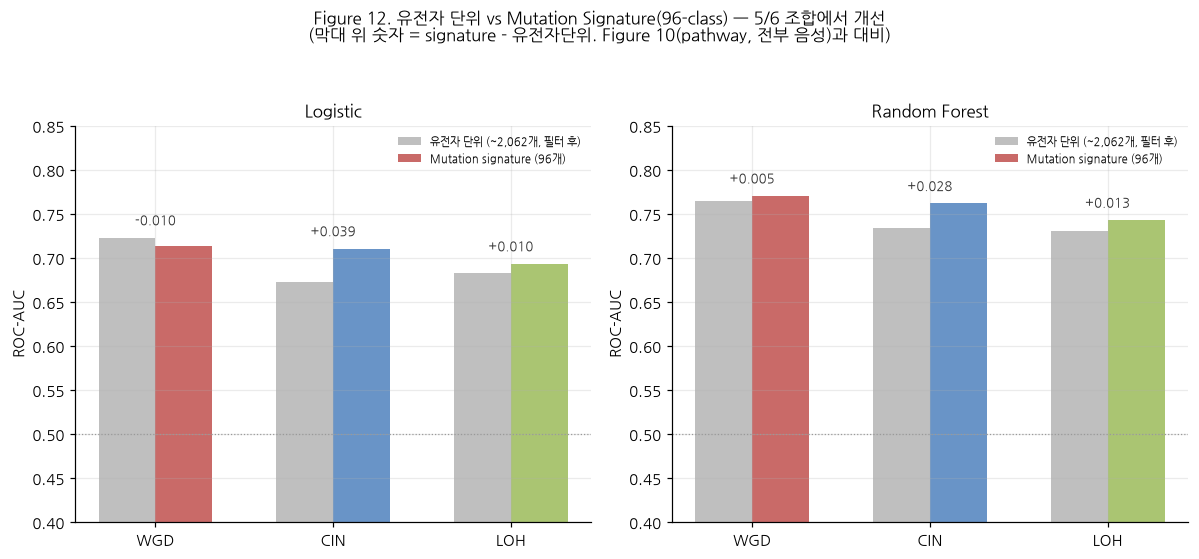

target         model  gene_level_auc  signature_auc     차이
   wgd      logistic           0.723          0.713 -0.010
   cin      logistic           0.672          0.711  0.039
   loh      logistic           0.683          0.693  0.010
   wgd random_forest           0.765          0.770  0.005
   cin random_forest           0.734          0.762  0.028
   loh random_forest           0.730          0.743  0.013


In [23]:
# Figure 12 — scripts 의 해당 plot 스크립트를 그대로 옮긴 것.
df = pd.read_csv(TABLES / "day24_signature_vs_gene.csv")
models = ["logistic", "random_forest"]
MODEL_LABEL2 = {"logistic": "Logistic", "random_forest": "Random Forest"}

fig, axes = plt.subplots(1, 2, figsize=(11, 4.8))
for ax, model in zip(axes, models):
    sub = df[df.model == model].set_index("target").reindex(list(TARGETS))
    x, width = np.arange(3), 0.32
    ax.bar(x - width / 2, sub.gene_level_auc, width,
           label="유전자 단위 (~2,062개, 필터 후)", color="#bfbfbf")
    ax.bar(x + width / 2, sub.signature_auc, width,
           label="Mutation signature (96개)", color=[PHENOTYPE_COLORS[t] for t in TARGETS], alpha=0.85)
    for i, (gene_auc, other) in enumerate(zip(sub.gene_level_auc, sub.signature_auc)):
        ax.text(i, max(gene_auc, other) + 0.015, f"{other - gene_auc:+.3f}",
                ha="center", fontsize=8.5, color="#333")
    ax.axhline(0.5, color="#999", ls=":", lw=0.8)
    ax.set_xticks(x)
    ax.set_xticklabels([TARGET_LABEL[t] for t in TARGETS])
    ax.set_ylim(0.4, 0.85)
    ax.set_ylabel("ROC-AUC")
    ax.set_title(MODEL_LABEL2[model])
    ax.legend(fontsize=7.5, loc="upper right")

fig.suptitle("Figure 12. 유전자 단위 vs Mutation Signature(96-class) — 5/6 조합에서 개선\n"
             "(막대 위 숫자 = signature - 유전자단위. Figure 10(pathway, 전부 음성)과 대비)", y=1.05, fontsize=11)
fig.tight_layout()
plt.show()
print(df.round(3).to_string(index=False))

**6개 조합 중 5개가 개선됐다.** 96개라는 훨씬 적은 feature 수로 유전자
\~2,062개 수준의 성능을 냈다. Signature 자체의 최소 패널(20\~30개로 95\~99% 유지)과
3-seed 재현성(변동폭 0.001\~0.005, 매우 안정적) 검증 결과는 아래 Figure
13/15에 있다.

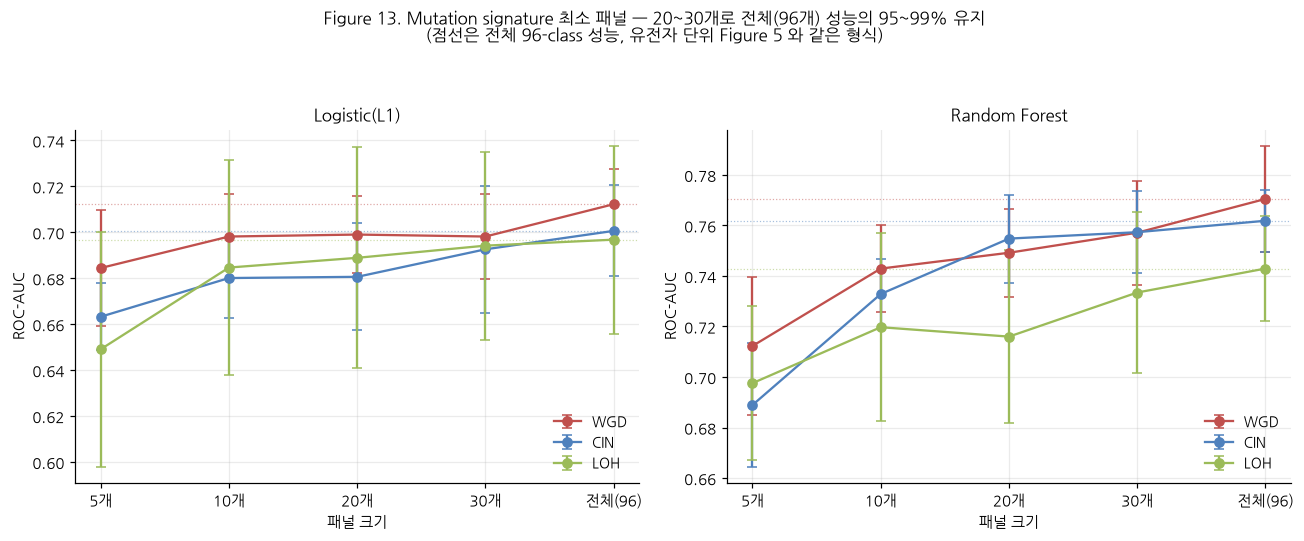

In [24]:
# Figure 13 — scripts/29_plot_signature_panel.py 를 그대로 옮긴 것.
sig_metrics = pd.read_csv(TABLES / "day26_signature_panel_metrics.csv")
SIZES = [5, 10, 20, 30]
order = [str(s) for s in SIZES] + ["all"]
SIG_MODEL_LABEL = {"logistic_l1": "Logistic(L1)", "random_forest": "Random Forest"}

fig, axes = plt.subplots(1, 2, figsize=(12, 4.6))
for ax, model in zip(axes, ("logistic_l1", "random_forest")):
    for target in TARGETS:
        sub = sig_metrics[(sig_metrics.model == model) & (sig_metrics.target == target)]
        g = sub.groupby(sub.panel_size.astype(str)).roc_auc
        mean, std = g.mean().reindex(order), g.std().reindex(order)
        ax.errorbar(range(len(order)), mean, yerr=std, marker="o", capsize=3,
                    label=TARGET_LABEL[target], color=PHENOTYPE_COLORS[target])
        full = mean.get("all")
        if pd.notna(full):
            ax.axhline(full, color=PHENOTYPE_COLORS[target], ls=":", lw=0.8, alpha=0.5)
    ax.set_xticks(range(len(order)))
    ax.set_xticklabels([f"{o}개" if o != "all" else "전체(96)" for o in order])
    ax.set_xlabel("패널 크기")
    ax.set_ylabel("ROC-AUC")
    ax.set_title(SIG_MODEL_LABEL[model])
    ax.legend(fontsize=9)

fig.suptitle("Figure 13. Mutation signature 최소 패널 — 20~30개로 전체(96개) 성능의 95~99% 유지\n"
             "(점선은 전체 96-class 성능, 유전자 단위 Figure 5 와 같은 형식)", y=1.06, fontsize=11)
fig.tight_layout()
plt.show()

## 11. 유전자 + Signature 결합 패널

두 축(유전자 정체성 / 변이 발생 과정)을 한 feature 공간에 합쳐서 함께 feature
selection을 시키면 어떻게 될까?

재현: `python scripts/32_combined_gene_signature_panel.py`.

In [25]:
combined = pd.read_csv(TABLES / "day32_combined_vs_single_summary.csv")
combined.round(3)

,model,target,결합,유전자만,signature만,결합-유전자,결합-signature
0,logistic_l1,wgd,0.791,0.723,0.713,0.068,0.078
1,logistic_l1,cin,0.746,0.672,0.711,0.074,0.035
2,logistic_l1,loh,0.755,0.683,0.693,0.072,0.062
3,random_forest,wgd,0.797,0.765,0.770,0.032,0.027
4,random_forest,cin,0.775,0.734,0.762,0.041,0.013
5,random_forest,loh,0.765,0.730,0.743,0.035,0.022


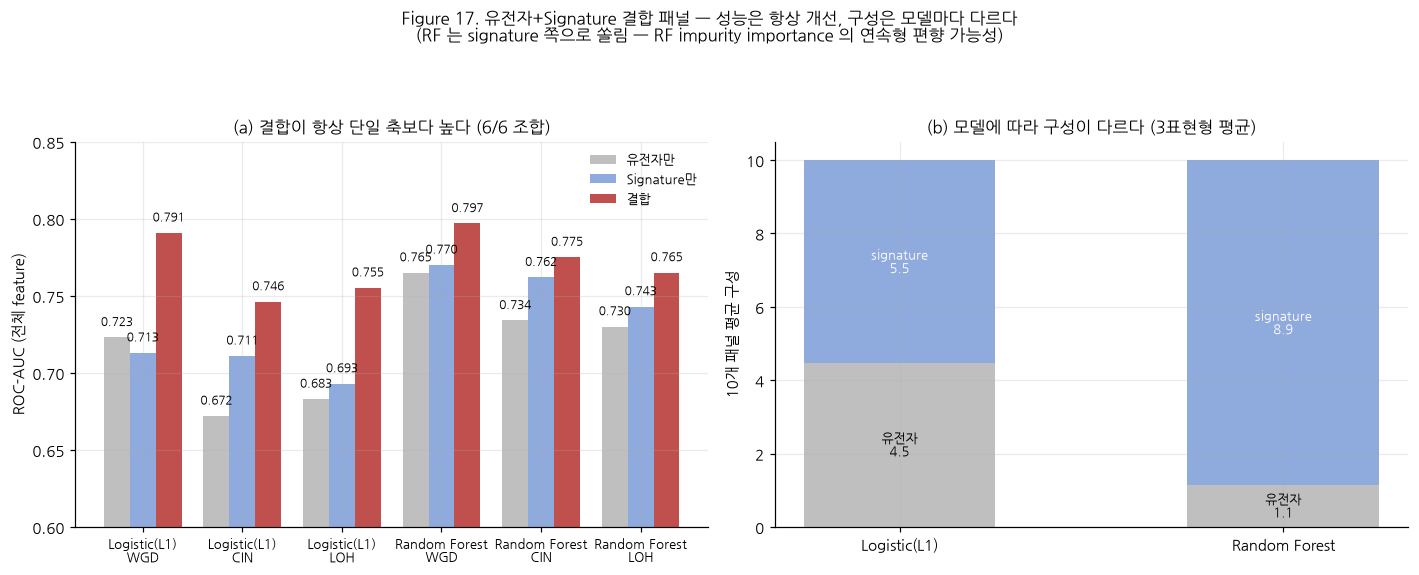

In [26]:
# Figure 17 — scripts/35_plot_combined_panel.py 를 그대로 옮긴 것.
summary = pd.read_csv(TABLES / "day32_combined_vs_single_summary.csv")
comp = pd.read_csv(TABLES / "day32_combined_panel_composition.csv")
CMODELS = ("logistic_l1", "random_forest")
CMODEL_LABEL = {"logistic_l1": "Logistic(L1)", "random_forest": "Random Forest"}

fig, axes = plt.subplots(1, 2, figsize=(13, 4.8))
ax = axes[0]
combos = [(m, t) for m in CMODELS for t in TARGETS]
x, width = np.arange(len(combos)), 0.26
pick = lambda col: [summary[(summary.model == m) & (summary.target == t)][col].iloc[0]
                    for m, t in combos]
gene_v, sig_v, combined_v = pick("유전자만"), pick("signature만"), pick("결합")

ax.bar(x - width, gene_v, width, label="유전자만", color="#bfbfbf")
ax.bar(x, sig_v, width, label="Signature만", color="#8faadc")
ax.bar(x + width, combined_v, width, label="결합", color="#c0504d")
for i, v in enumerate(gene_v):
    ax.text(i - width, v + 0.008, f"{v:.3f}", ha="center", fontsize=8)
for i, v in enumerate(sig_v):
    ax.text(i, v + 0.008, f"{v:.3f}", ha="center", fontsize=8)
for i, v in enumerate(combined_v):
    ax.text(i + width, v + 0.008, f"{v:.3f}", ha="center", fontsize=8)
ax.set_xticks(x)
ax.set_xticklabels([f"{CMODEL_LABEL[m]}\n{TARGET_LABEL[t]}" for m, t in combos], fontsize=8.5)
ax.set_ylabel("ROC-AUC (전체 feature)")
ax.set_ylim(0.6, 0.85)
ax.set_title("(a) 결합이 항상 단일 축보다 높다 (6/6 조합)")
ax.legend(fontsize=8.5)

ax2 = axes[1]
comp10 = comp[comp.panel_size == 10].groupby("model")[["n_genes", "n_sig"]].mean().reindex(CMODELS)
xm = np.arange(len(CMODELS))
ax2.bar(xm, comp10.n_genes, 0.5, label="유전자", color="#bfbfbf")
ax2.bar(xm, comp10.n_sig, 0.5, bottom=comp10.n_genes, label="Signature class", color="#8faadc")
for i, (g, s) in enumerate(zip(comp10.n_genes, comp10.n_sig)):
    ax2.text(i, g / 2, f"유전자\n{g:.1f}", ha="center", va="center", fontsize=8.5)
    ax2.text(i, g + s / 2, f"signature\n{s:.1f}", ha="center", va="center", fontsize=8.5, color="white")
ax2.set_xticks(list(xm))
ax2.set_xticklabels([CMODEL_LABEL[m] for m in CMODELS])
ax2.set_ylabel("10개 패널 평균 구성")
ax2.set_title("(b) 모델에 따라 구성이 다르다 (3표현형 평균)")

fig.suptitle("Figure 17. 유전자+Signature 결합 패널 — 성능은 항상 개선, 구성은 모델마다 다르다\n"
             "(RF 는 signature 쪽으로 쏠림 — RF impurity importance 의 연속형 편향 가능성)",
             y=1.08, fontsize=11)
fig.tight_layout()
plt.show()

**6개 조합 전부 결합이 단일 축(유전자만/signature만)보다 높다**
(+0.013\~+0.078). Random Forest+WGD(0.797)는 이 프로젝트 전체에서 가장 높은
ROC-AUC다. 다만 "결합 시 무엇이 선택되는가"는 모델에 따라 다르다 — Random
Forest는 Random Forest importance의 cardinality 편향으로 signature 쪽에 크게
쏠리고(TP53 한 개만 생존), Logistic(L1)은 균형 잡힌 구성을 보이며 기존 핵심
축(TP53/ID3/BRAF/CREBBP)이 그대로 유지된다.

### CIN 회귀 기반 패널 재검증

이진화 손실이 있었던 CIN/Elastic Net 조합에서, 분류 대신 회귀로 다시 뽑은
패널이 기존 분류 패널과 얼마나 겹치는지 확인한다.

재현: `python scripts/28_cin_regression_panel.py`.

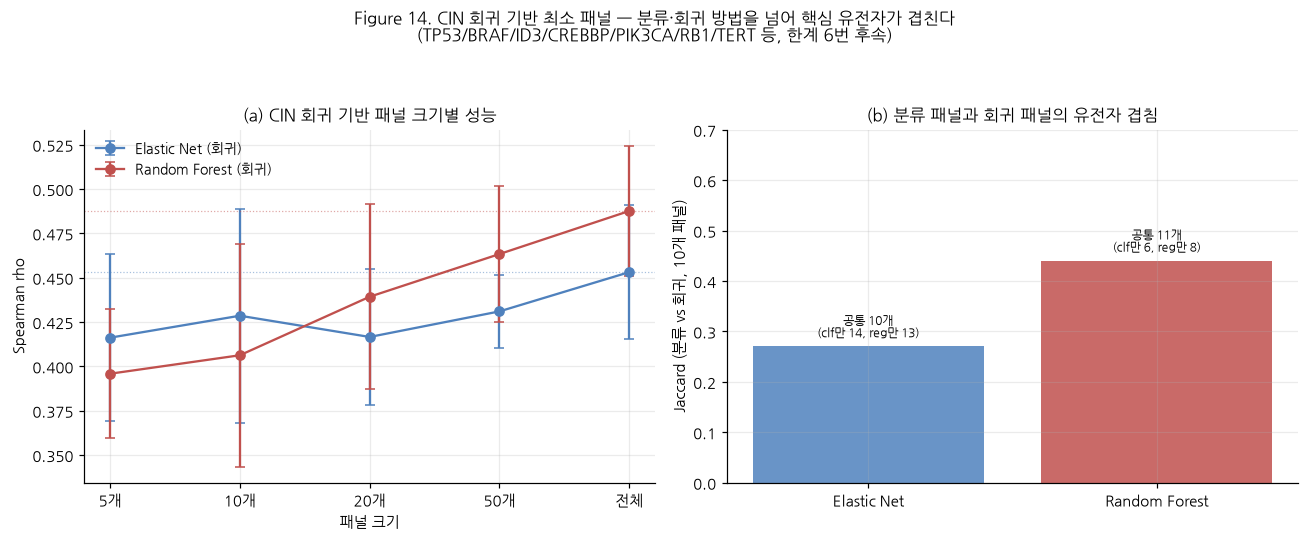

            model  jaccard  n_common  n_clf_only  n_reg_only
  elastic_net_reg     0.27        10          14          13
random_forest_reg     0.44        11           6           8


In [27]:
# Figure 14 — scripts/30_plot_cin_regression_panel.py 를 그대로 옮긴 것.
reg_metrics = pd.read_csv(TABLES / "day28_cin_regression_panel_metrics.csv")
reg_picks = pd.read_csv(TABLES / "day28_cin_regression_panel_picks.csv")
RMODELS = ("elastic_net_reg", "random_forest_reg")
RMODEL_LABEL = {"elastic_net_reg": "Elastic Net (회귀)", "random_forest_reg": "Random Forest (회귀)"}
CLF_MODEL_OF = {"elastic_net_reg": "elastic_net", "random_forest_reg": "random_forest"}
CLF_LABEL = {"elastic_net_reg": "Elastic Net", "random_forest_reg": "Random Forest"}
RSIZES = [5, 10, 20, 50]
RCOLORS = {"elastic_net_reg": "#4f81bd", "random_forest_reg": "#c0504d"}

rows = []
for m in RMODELS:
    clf_picks = pd.read_csv(TABLES / f"day12_panel_picks_{CLF_MODEL_OF[m]}.csv")
    clf_genes = set(clf_picks[(clf_picks.target == "cin") & (clf_picks.panel_size == 10)]
                    .feature.str.split(" \\(").str[0])
    reg_genes = set(reg_picks[(reg_picks.model == m) & (reg_picks.panel_size == 10)]
                    .feature.str.split(" \\(").str[0])
    union = clf_genes | reg_genes
    rows.append({"model": m, "jaccard": len(clf_genes & reg_genes) / len(union) if union else float("nan"),
                 "n_common": len(clf_genes & reg_genes), "n_clf_only": len(clf_genes - reg_genes),
                 "n_reg_only": len(reg_genes - clf_genes)})
overlap = pd.DataFrame(rows)

fig, axes = plt.subplots(1, 2, figsize=(12, 4.6))
ax = axes[0]
order = [str(s) for s in RSIZES] + ["all"]
for m in RMODELS:
    sub = reg_metrics[reg_metrics.model == m]
    g = sub.groupby(sub.panel_size.astype(str)).spearman_rho
    mean, std = g.mean().reindex(order), g.std().reindex(order)
    ax.errorbar(range(len(order)), mean, yerr=std, marker="o", capsize=3,
                label=RMODEL_LABEL[m], color=RCOLORS[m])
    full = mean.get("all")
    if pd.notna(full):
        ax.axhline(full, color=RCOLORS[m], ls=":", lw=0.8, alpha=0.5)
ax.set_xticks(range(len(order)))
ax.set_xticklabels([f"{o}개" if o != "all" else "전체" for o in order])
ax.set_xlabel("패널 크기")
ax.set_ylabel("Spearman rho")
ax.set_title("(a) CIN 회귀 기반 패널 크기별 성능")
ax.legend(fontsize=9)

ax2 = axes[1]
ax2.bar(range(len(RMODELS)), overlap.jaccard, color=[RCOLORS[m] for m in RMODELS], alpha=0.85)
for i, row in overlap.iterrows():
    ax2.text(i, row.jaccard + 0.02, f"공통 {row.n_common}개\n(clf만 {row.n_clf_only},"
             f" reg만 {row.n_reg_only})", ha="center", fontsize=8)
ax2.set_xticks(list(range(len(RMODELS))))
ax2.set_xticklabels([CLF_LABEL[m] for m in RMODELS])
ax2.set_ylabel("Jaccard (분류 vs 회귀, 10개 패널)")
ax2.set_ylim(0, 0.7)
ax2.set_title("(b) 분류 패널과 회귀 패널의 유전자 겹침")

fig.suptitle("Figure 14. CIN 회귀 기반 최소 패널 — 분류·회귀 방법을 넘어 핵심 유전자가 겹친다\n"
             "(TP53/BRAF/ID3/CREBBP/PIK3CA/RB1/TERT 등, 한계 6번 후속)", y=1.06, fontsize=11)
fig.tight_layout()
plt.show()
print(overlap.round(3).to_string(index=False))

분류-회귀 두 방법을 넘어 TP53/BRAF/ID3/CREBBP/PIK3CA/RB1/TERT 핵심 축이 그대로
겹친다(Jaccard 0.27\~0.44) — 이진화 손실이 "어떤 유전자가 선택되는가"에는 크게
반영되지 않았다는 뜻이다.

## 12. Sensitivity/Specificity 트레이드오프

표현 방식(유전자 → signature → 결합)을 바꾸면 sensitivity/specificity 우세가
어떻게 이동하는지 본다.

재현: `python scripts/36_plot_sens_spec_tradeoff.py`.

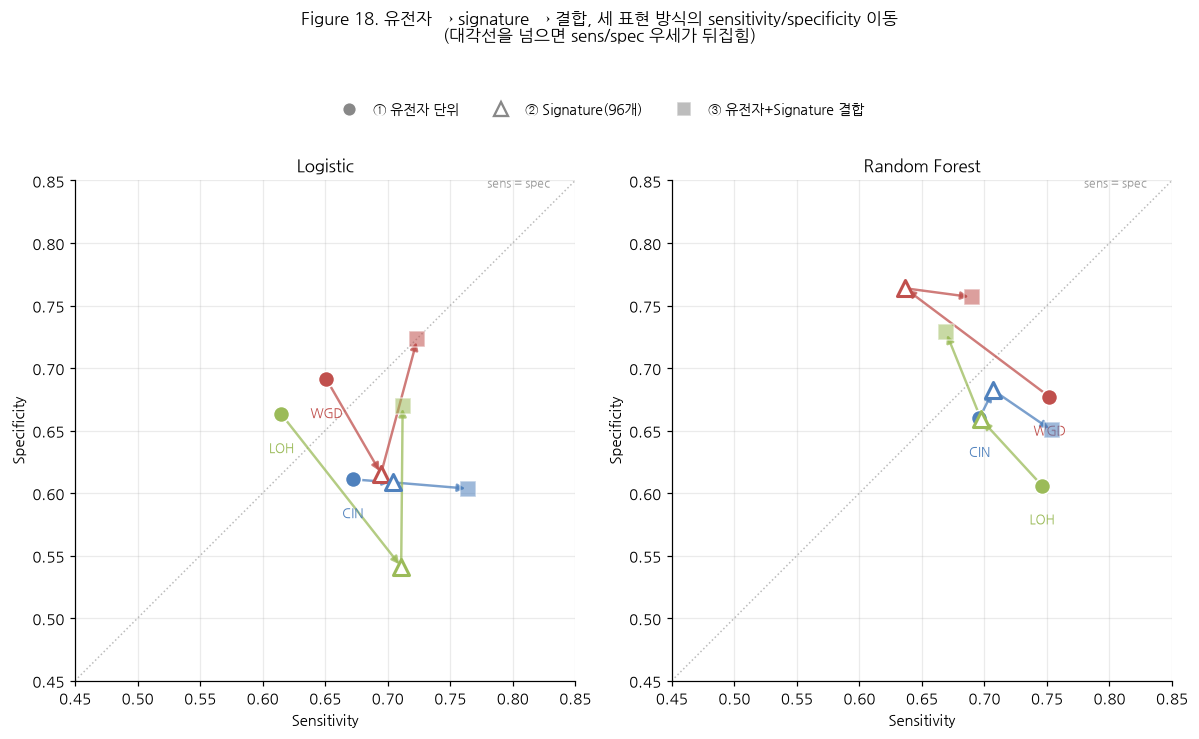

In [28]:
# Figure 18 — scripts/36_plot_sens_spec_tradeoff.py 를 그대로 옮긴 것.
gene = pd.read_csv(TABLES / "day10_model_comparison.csv")
sig = (pd.read_csv(TABLES / "day24_signature_summary.csv")
       .groupby(["target", "model"])[["sensitivity", "specificity"]].mean().reset_index())
comb_raw = pd.read_csv(TABLES / "day32_combined_panel_metrics.csv")
comb = (comb_raw[comb_raw.panel_size.astype(str) == "all"]
        .groupby(["target", "model"])[["sensitivity", "specificity"]].mean().reset_index())
SMODELS = ("logistic", "random_forest")
SMODEL_LABEL = {"logistic": "Logistic", "random_forest": "Random Forest"}
COMBINED_MODEL_OF = {"logistic": "logistic_l1", "random_forest": "random_forest"}

fig, axes = plt.subplots(1, 2, figsize=(11, 5.6))
for ax, model in zip(axes, SMODELS):
    ax.plot([0.45, 0.85], [0.45, 0.85], color="#bbb", ls=":", lw=1, zorder=1)
    ax.text(0.83, 0.845, "sens = spec", fontsize=8, color="#999", ha="right")
    for target in TARGETS:
        g = gene[(gene.target == target) & (gene.model == model)].iloc[0]
        s = sig[(sig.target == target) & (sig.model == model)].iloc[0]
        c = comb[(comb.target == target) & (comb.model == COMBINED_MODEL_OF[model])].iloc[0]
        color = PHENOTYPE_COLORS[target]
        points = [(g.sensitivity, g.specificity), (s.sensitivity, s.specificity),
                  (c.sensitivity, c.specificity)]
        for (x0, y0), (x1, y1) in zip(points[:-1], points[1:]):
            ax.annotate("", xy=(x1, y1), xytext=(x0, y0),
                        arrowprops=dict(arrowstyle="-|>", color=color, lw=1.6, alpha=0.75), zorder=2)
        ax.scatter(*points[0], marker="o", s=110, color=color, edgecolor="white",
                   linewidth=1, zorder=3)
        ax.scatter(*points[1], marker="^", s=110, facecolor="white", edgecolor=color,
                   linewidth=2, zorder=3)
        ax.scatter(*points[2], marker="s", s=100, color=color, edgecolor="white",
                   linewidth=1, alpha=0.55, zorder=3)
        ax.text(points[0][0], points[0][1] - 0.022, TARGET_LABEL[target],
                fontsize=8.5, color=color, ha="center", va="top")
    ax.set_xlim(0.45, 0.85)
    ax.set_ylim(0.45, 0.85)
    ax.set_xlabel("Sensitivity")
    ax.set_ylabel("Specificity")
    ax.set_title(SMODEL_LABEL[model])
    ax.set_aspect("equal")

handles = [
    plt.Line2D([0], [0], marker="o", color="w", markerfacecolor="#888", markersize=9, label="① 유전자 단위"),
    plt.Line2D([0], [0], marker="^", color="w", markerfacecolor="white", markeredgecolor="#888",
               markeredgewidth=1.5, markersize=9, label="② Signature(96개)"),
    plt.Line2D([0], [0], marker="s", color="w", markerfacecolor="#888", markersize=9,
               alpha=0.55, label="③ 유전자+Signature 결합"),
]
fig.legend(handles=handles, loc="upper center", ncol=3, fontsize=9, bbox_to_anchor=(0.5, 1.03))
fig.suptitle("Figure 18. 유전자 → signature → 결합, 세 표현 방식의 sensitivity/specificity 이동\n"
             "(대각선을 넘으면 sens/spec 우세가 뒤집힘)", y=1.16, fontsize=11)
fig.tight_layout()
plt.show()

CIN은 두 모델 모두 세 단계 내내 sensitivity 우세를 유지하는 반면, WGD와 LOH는
표현 방식을 바꿀 때 대각선(sens=spec)을 넘어가는 지점이 있다 — 표현형에 따라
"표현 방식 선택"이 예측 오류의 방향 자체를 바꿀 수 있다는 뜻이다.

## 13. TCGA 외부 코호트 검증

DepMap 세포주가 아니라 실제 환자 종양 조직(TCGA)에서 WGD를 외부 검증한다.
DepMap 전체로 학습한 모델을 그대로 TCGA에 적용했다(damaging feature만,
hotspot 대응 데이터 없음).

재현: `python scripts/21_tcga_validation.py`.

In [29]:
tcga = pd.read_csv(TABLES / "day21_tcga_validation_summary.csv")
tcga

,stage,roc_auc,n
0,"DepMap 내부(damaging-only, random 5-fold)",0.762229,1631
1,TCGA 외부 검증,0.594063,10261


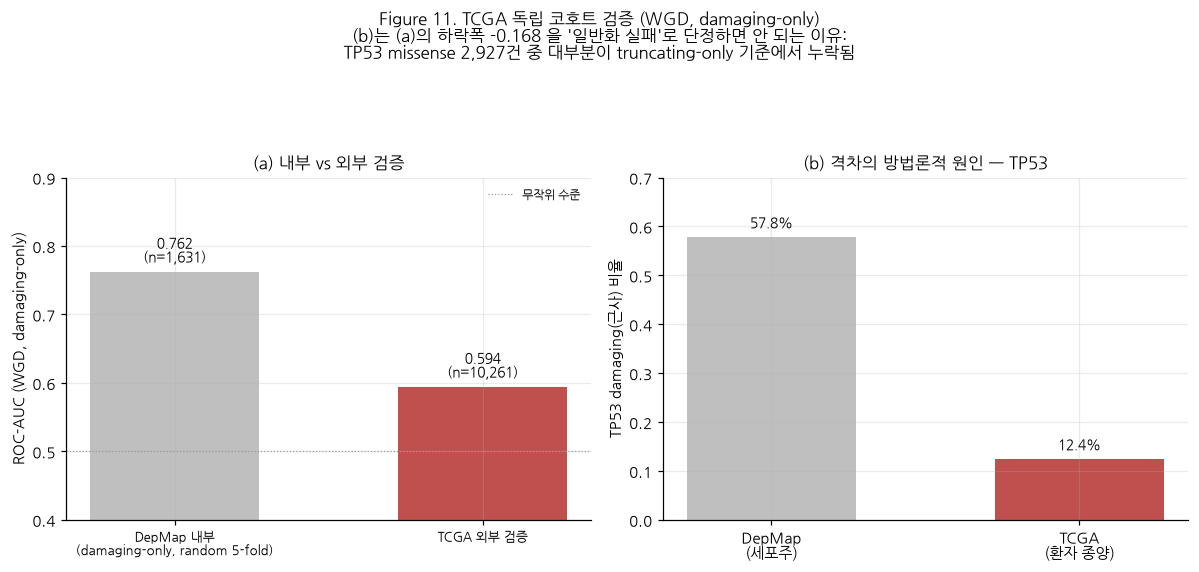

                                  stage  roc_auc     n
DepMap 내부(damaging-only, random 5-fold) 0.762229  1631
                             TCGA 외부 검증 0.594063 10261


In [30]:
# Figure 11 — scripts/22_plot_tcga_validation.py 를 그대로 옮긴 것.
tcga = pd.read_csv(TABLES / "day21_tcga_validation_summary.csv")

fig, axes = plt.subplots(1, 2, figsize=(11, 4.6))
ax = axes[0]
bars = ax.bar(tcga.stage.str.replace("(", "\n(", regex=False), tcga.roc_auc,
              color=["#bfbfbf", PHENOTYPE_COLORS["wgd"]], width=0.55)
for b, v, n in zip(bars, tcga.roc_auc, tcga.n):
    ax.text(b.get_x() + b.get_width() / 2, v + 0.015, f"{v:.3f}\n(n={n:,})",
            ha="center", fontsize=9)
ax.axhline(0.5, color="#999", ls=":", lw=0.8, label="무작위 수준")
ax.set_ylim(0.4, 0.9)
ax.set_ylabel("ROC-AUC (WGD, damaging-only)")
ax.set_title("(a) 내부 vs 외부 검증")
ax.legend(fontsize=8)
ax.tick_params(axis="x", labelsize=8.5)

ax = axes[1]
tp53 = pd.DataFrame({"cohort": ["DepMap\n(세포주)", "TCGA\n(환자 종양)"], "rate": [0.578, 0.124]})
ax.bar(tp53.cohort, tp53.rate, color=["#bfbfbf", PHENOTYPE_COLORS["wgd"]], width=0.55)
for i, v in enumerate(tp53.rate):
    ax.text(i, v + 0.02, f"{v:.1%}", ha="center", fontsize=9)
ax.set_ylim(0, 0.7)
ax.set_ylabel("TP53 damaging(근사) 비율")
ax.set_title("(b) 격차의 방법론적 원인 — TP53")

fig.suptitle("Figure 11. TCGA 독립 코호트 검증 (WGD, damaging-only)\n"
             "(b)는 (a)의 하락폭 -0.168 을 '일반화 실패'로 단정하면 안 되는 이유:\n"
             "TP53 missense 2,927건 중 대부분이 truncating-only 기준에서 누락됨",
             y=1.12, fontsize=11)
fig.tight_layout()
plt.show()
print(tcga.to_string(index=False))

내부(0.762) 대비 외부(0.594)로 크게 떨어지지만, TCGA의 TP53 damaging 근사
비율이 DepMap보다 훨씬 낮다(57.8% vs 12.4%) — TP53의 주된 불활성화 경로인
missense 변이를 truncating-only 근사가 놓치기 때문으로, **0.594는 실제
일반화 성능의 하한 추정치**에 가깝다.

## 14. 탐색적 분석 — 연관성 검정 / UMAP / CCA / 군집

팀원(psh03)이 별도로 만든 탐색 시각화를 이 저장소 파이프라인 규약에 맞춰
옮긴 것이다 (`scripts/42_mutation_association.py` \~ `scripts/48_plot_selection_dendrogram.py`,
원본은 `docs/research/2026-08-22/depmap_viz/`).

**주의** — 이 절은 outcome/model 기반 feature selection 없이 mutation *빈도*만으로
필터링한 전체 코호트 탐색 분석이다. 위 3\~13절의 nested CV 성능 추정치를
대체하지 않는다. CIN/LOH 는 전체 코호트 중앙값으로 high/low 를 나눠 검정에만 쓴다.

빈도 필터 통과 feature: 617개 (prevalence >= 1.0%)


[WGD] FDR < 0.05: 28개 / 617개 (상위: TP53 (7157)_damaging, q=7.05e-38)


[CIN] FDR < 0.05: 62개 / 617개 (상위: TP53 (7157)_damaging, q=1.39e-26)


[LOH] FDR < 0.05: 110개 / 617개 (상위: TP53 (7157)_damaging, q=1.13e-30)


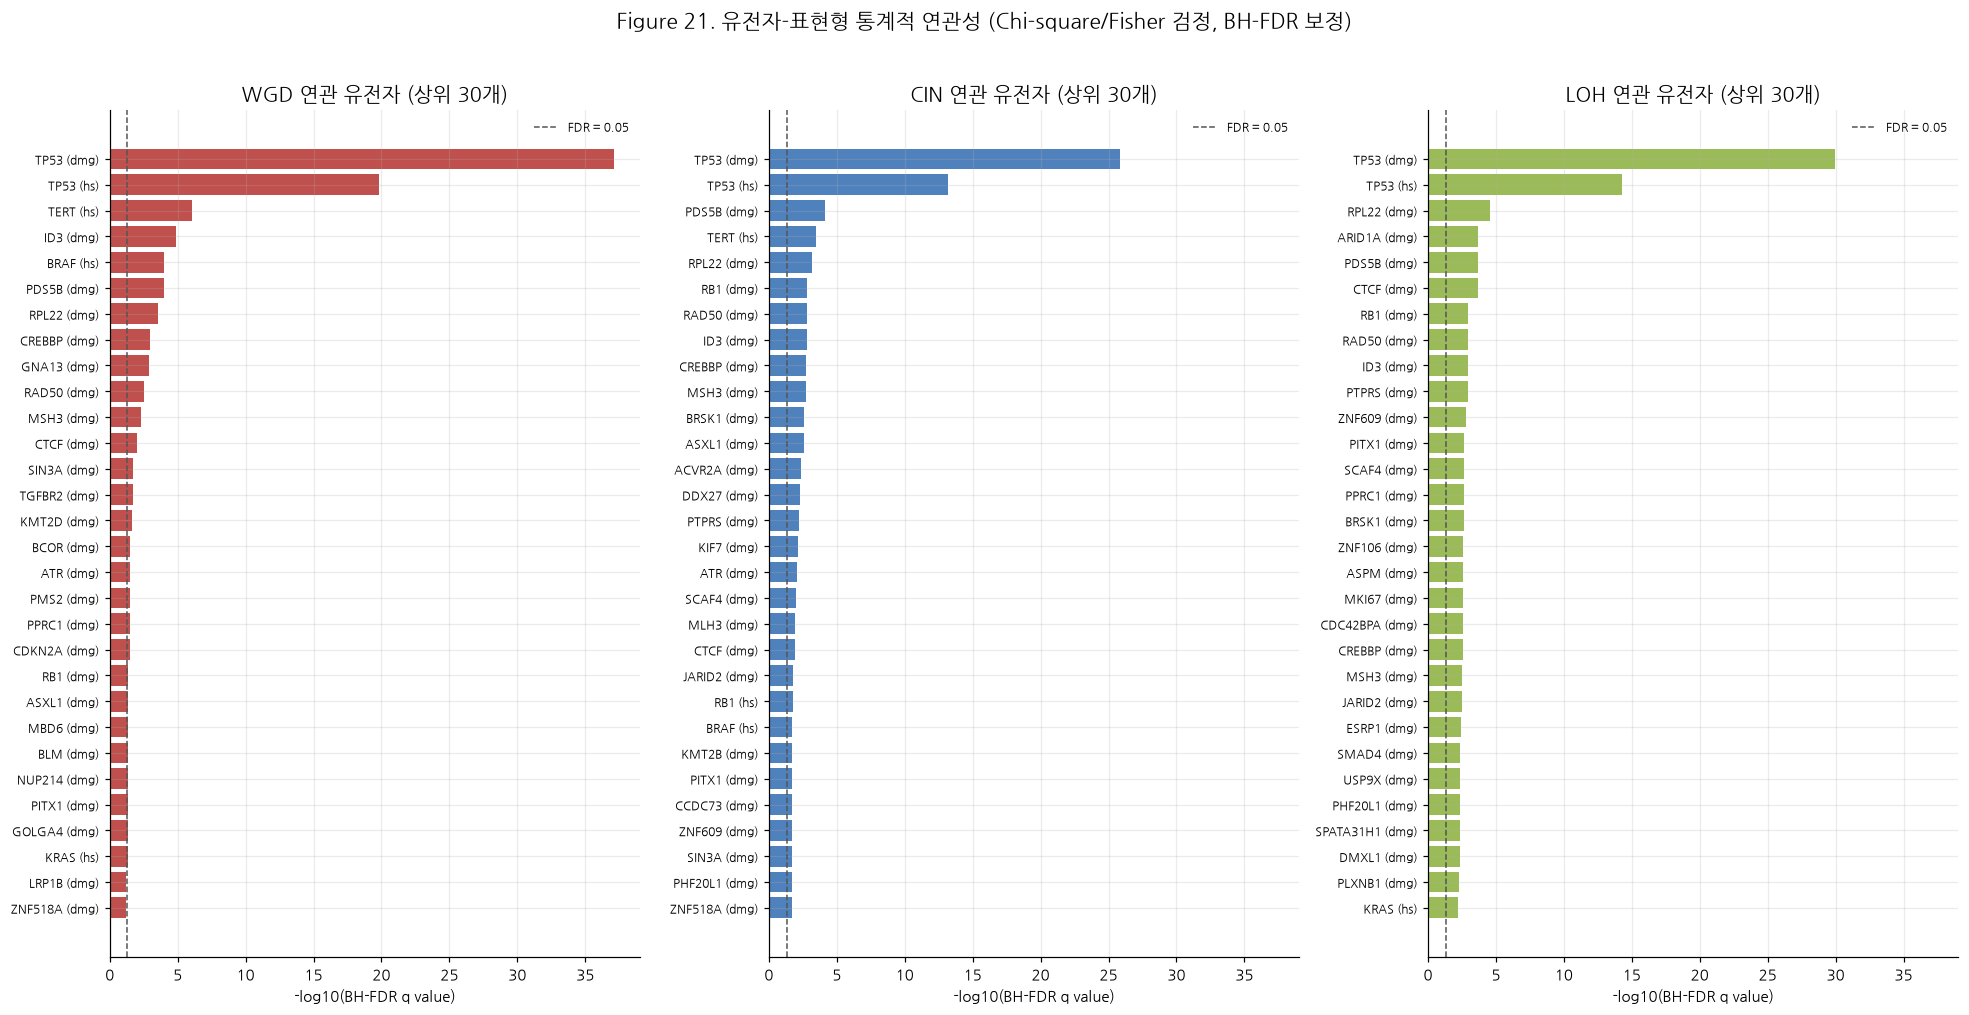

In [31]:
# Figure 21/22 — scripts/42_mutation_association.py + 43_plot_mutation_association.py
# 여기서 chi-square/Fisher 검정을 실제로 수행한다 (CSV 를 읽어오지 않는다).
import re

from scipy.stats import chi2_contingency, fisher_exact

MIN_PREVALENCE = 0.01   # mutation 빈도 1% 미만 feature 제외 (outcome 과 무관한 필터)


def bh_fdr(p_values: pd.Series) -> pd.Series:
    """Benjamini-Hochberg FDR q-value (statsmodels 의존성 없이)."""
    p = p_values.to_numpy(dtype=float)
    order = np.argsort(p)
    ranked = p[order] * len(p) / np.arange(1, len(p) + 1)
    ranked = np.minimum.accumulate(ranked[::-1])[::-1]
    q = np.empty_like(ranked)
    q[order] = np.minimum(ranked, 1.0)
    return pd.Series(q, index=p_values.index)


# WGD 는 원래 binary, CIN/LOH 는 전체 코호트 중앙값으로 탐색용 이진화
labels_bin = pd.DataFrame(index=cohort_y.index)
labels_bin["wgd"] = cohort_y["wgd"].astype(int)
for _t in ("cin", "loh"):
    labels_bin[_t] = (cohort_y[_t] >= cohort_y[_t].median()).astype(int)

_prev = cohort_X.mean(axis=0)
X_assoc = cohort_X.loc[:, _prev[_prev >= MIN_PREVALENCE].sort_values(ascending=False).index]
print(f"빈도 필터 통과 feature: {X_assoc.shape[1]}개 (prevalence >= {MIN_PREVALENCE:.1%})")


def association_tests(X, labels, target):
    """feature × binary phenotype 의 Fisher/chi-square, OR 와 95% CI, BH-FDR."""
    outcome = labels[target].to_numpy()
    rows = []
    for feature in X.columns:
        mut = X[feature].to_numpy().astype(int)
        a = int(((mut == 1) & (outcome == 1)).sum())
        b = int(((mut == 1) & (outcome == 0)).sum())
        c = int(((mut == 0) & (outcome == 1)).sum())
        d = int(((mut == 0) & (outcome == 0)).sum())
        table = np.array([[a, b], [c, d]])
        if (chi2_contingency(table, correction=False).expected_freq < 5).any():
            odds_ratio, p_value = fisher_exact(table)
            test = "Fisher exact"
        else:
            _, p_value, _, _ = chi2_contingency(table, correction=False)
            odds_ratio = (a * d) / (b * c) if b and c else np.inf
            test = "Chi-square"
        # 0 cell 에서 OR/CI 가 무한대가 되지 않도록 Haldane-Anscombe 보정
        aa, bb, cc, dd = np.array([a, b, c, d], dtype=float) + 0.5
        log_or = np.log((aa * dd) / (bb * cc))
        se = np.sqrt(1 / aa + 1 / bb + 1 / cc + 1 / dd)
        rows.append({"feature": feature, "test": test, "odds_ratio": odds_ratio,
                     "odds_ratio_ci_low": np.exp(log_or - 1.96 * se),
                     "odds_ratio_ci_high": np.exp(log_or + 1.96 * se), "p_value": p_value})
    out = pd.DataFrame(rows).sort_values("p_value").reset_index(drop=True)
    out["fdr_q_value"] = bh_fdr(out["p_value"])
    return out


assoc = {}
for _t in TARGETS:
    assoc[_t] = association_tests(X_assoc, labels_bin, _t)
    _n = int((assoc[_t].fdr_q_value < 0.05).sum())
    print(f"[{TARGET_LABEL[_t]}] FDR < 0.05: {_n}개 / {len(assoc[_t])}개 "
          f"(상위: {assoc[_t].iloc[0].feature}, q={assoc[_t].iloc[0].fdr_q_value:.2e})")


def shorten_feature(name: str) -> str:
    name = re.sub(r"\s*\(\d+\)", "", name)
    return name.replace("_damaging", " (dmg)").replace("_hotspot", " (hs)")


# --- Figure 21. 표현형별 상위 30개 연관 유전자 ---
tops, max_val = {}, 0.0
for _t in TARGETS:
    top30 = assoc[_t].head(30).copy().sort_values("fdr_q_value", ascending=False)
    top30["minus_log10_fdr"] = -np.log10(top30.fdr_q_value.clip(lower=1e-300))
    top30["short_feature"] = top30.feature.map(shorten_feature)
    tops[_t] = top30
    max_val = max(max_val, top30.minus_log10_fdr.max())

fig, axes = plt.subplots(1, 3, figsize=(18, 9))
for ax, _t in zip(axes, TARGETS):
    top30 = tops[_t]
    ax.barh(top30.short_feature, top30.minus_log10_fdr, color=PHENOTYPE_COLORS[_t])
    ax.axvline(-np.log10(0.05), color="#555", ls="--", lw=1, label="FDR = 0.05")
    ax.set_title(f"{TARGET_LABEL[_t]} 연관 유전자 (상위 30개)", fontsize=13)
    ax.set_xlabel("-log10(BH-FDR q value)")
    ax.set_xlim(0, max_val * 1.05)
    ax.tick_params(axis="y", labelsize=8)
    ax.legend(fontsize=8)
fig.suptitle("Figure 21. 유전자-표현형 통계적 연관성 (Chi-square/Fisher 검정, BH-FDR 보정)",
             y=1.02, fontsize=14)
fig.tight_layout()
plt.show()

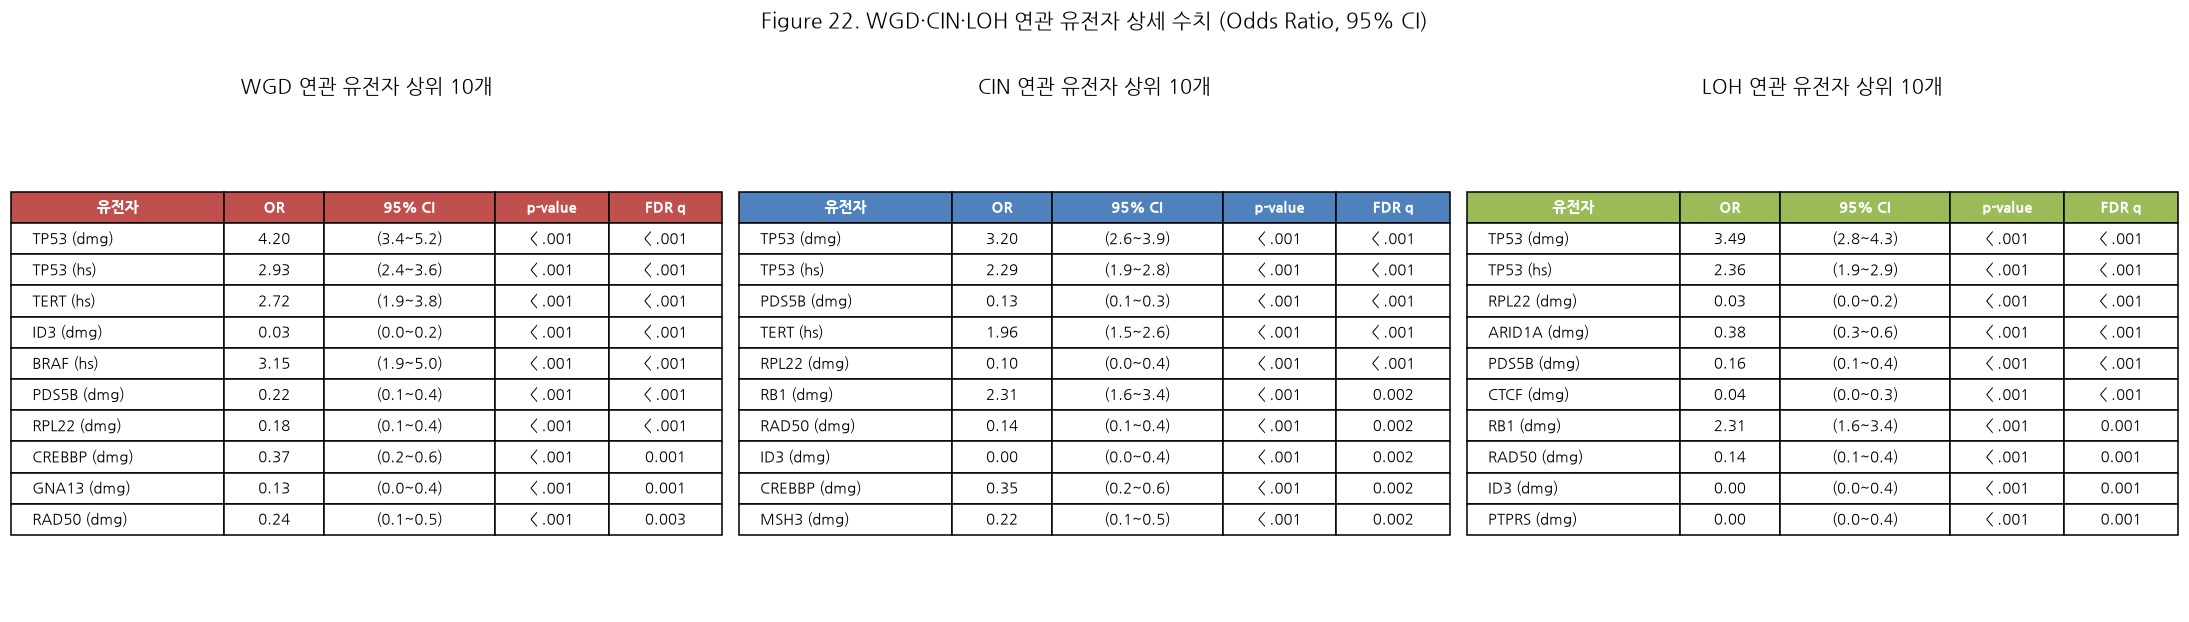

In [32]:
# Figure 22 — 상위 10개 연관 유전자 상세 수치 (OR, 95% CI)
columns = ["유전자", "OR", "95% CI", "p-value", "FDR q"]


def format_row(row):
    or_str = f"{row.odds_ratio:.2f}" if np.isfinite(row.odds_ratio) else "inf"
    ci_str = f"({row.odds_ratio_ci_low:.1f}~{row.odds_ratio_ci_high:.1f})"
    p_str = "< .001" if row.p_value < 0.001 else f"{row.p_value:.3f}"
    q_str = "< .001" if row.fdr_q_value < 0.001 else f"{row.fdr_q_value:.3f}"
    return [shorten_feature(row.feature), or_str, ci_str, p_str, q_str]


fig, axes = plt.subplots(1, 3, figsize=(20, 5.5))
for ax, _t in zip(axes, TARGETS):
    rows = [format_row(r) for _, r in assoc[_t].head(10).iterrows()]
    ax.axis("off")
    table = ax.table(cellText=rows, colLabels=columns, loc="center", cellLoc="center",
                     colWidths=[0.30, 0.14, 0.24, 0.16, 0.16])
    table.auto_set_font_size(False)
    table.set_fontsize(9.5)
    table.scale(1, 1.6)
    for j in range(len(columns)):
        table[0, j].set_facecolor(PHENOTYPE_COLORS[_t])
        table[0, j].set_text_props(color="white", weight="bold")
    for i in range(1, len(rows) + 1):
        table[i, 0].set_text_props(ha="left")
    ax.set_title(f"{TARGET_LABEL[_t]} 연관 유전자 상위 10개", fontsize=13, pad=15)
fig.suptitle("Figure 22. WGD·CIN·LOH 연관 유전자 상세 수치 (Odds Ratio, 95% CI)",
             y=1.02, fontsize=14)
fig.tight_layout()
plt.show()

/home/kali/adni-shared/AI-bio-proj-team-1/.venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


UMAP 직접 계산 완료 — feature 80개, 세포주 1,631개


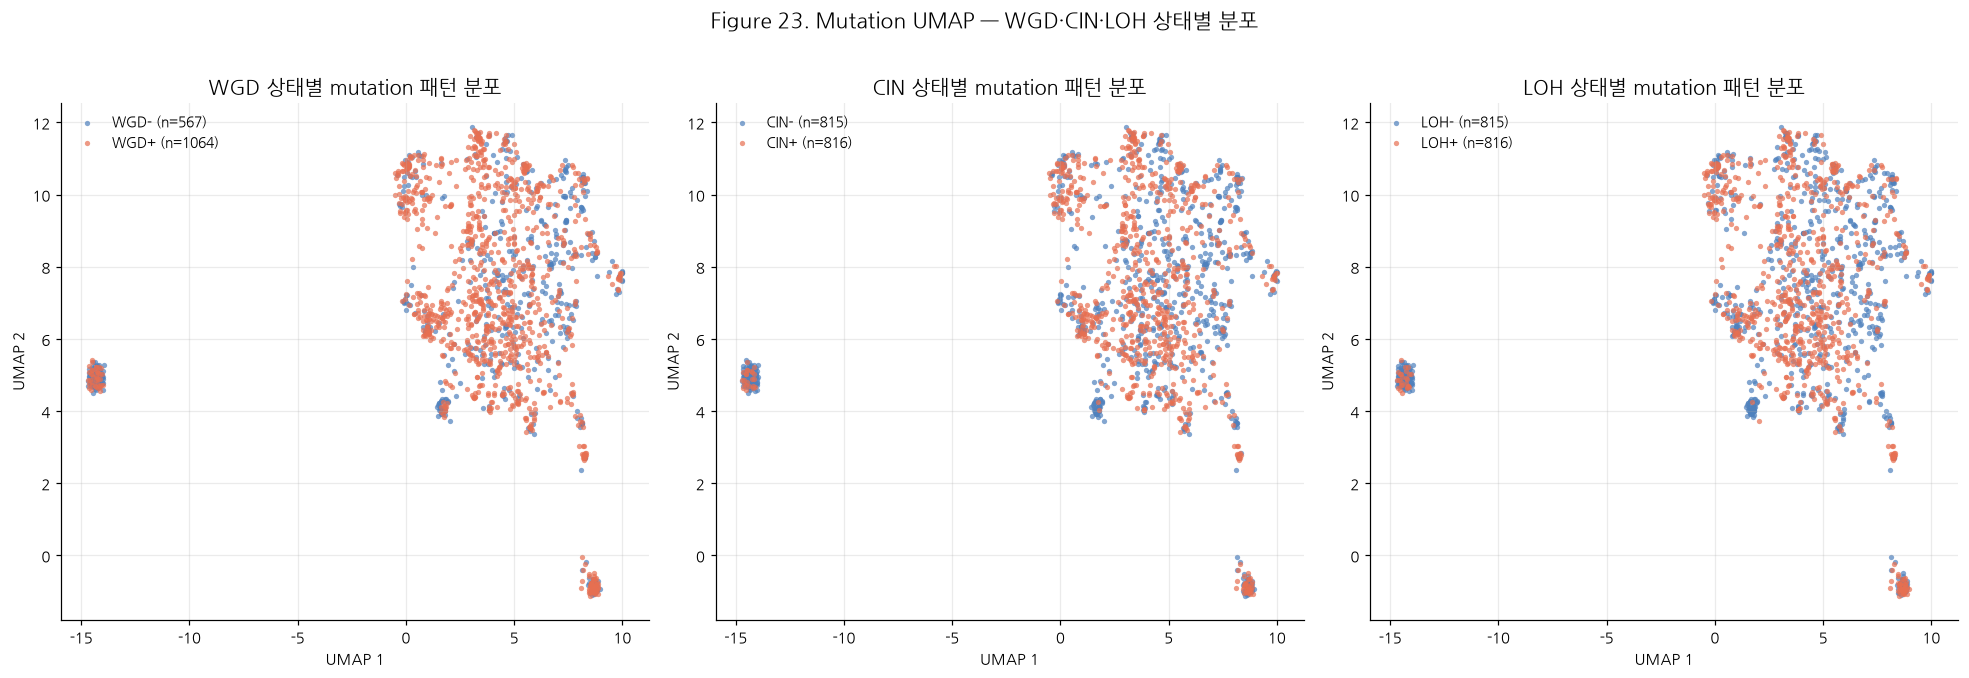

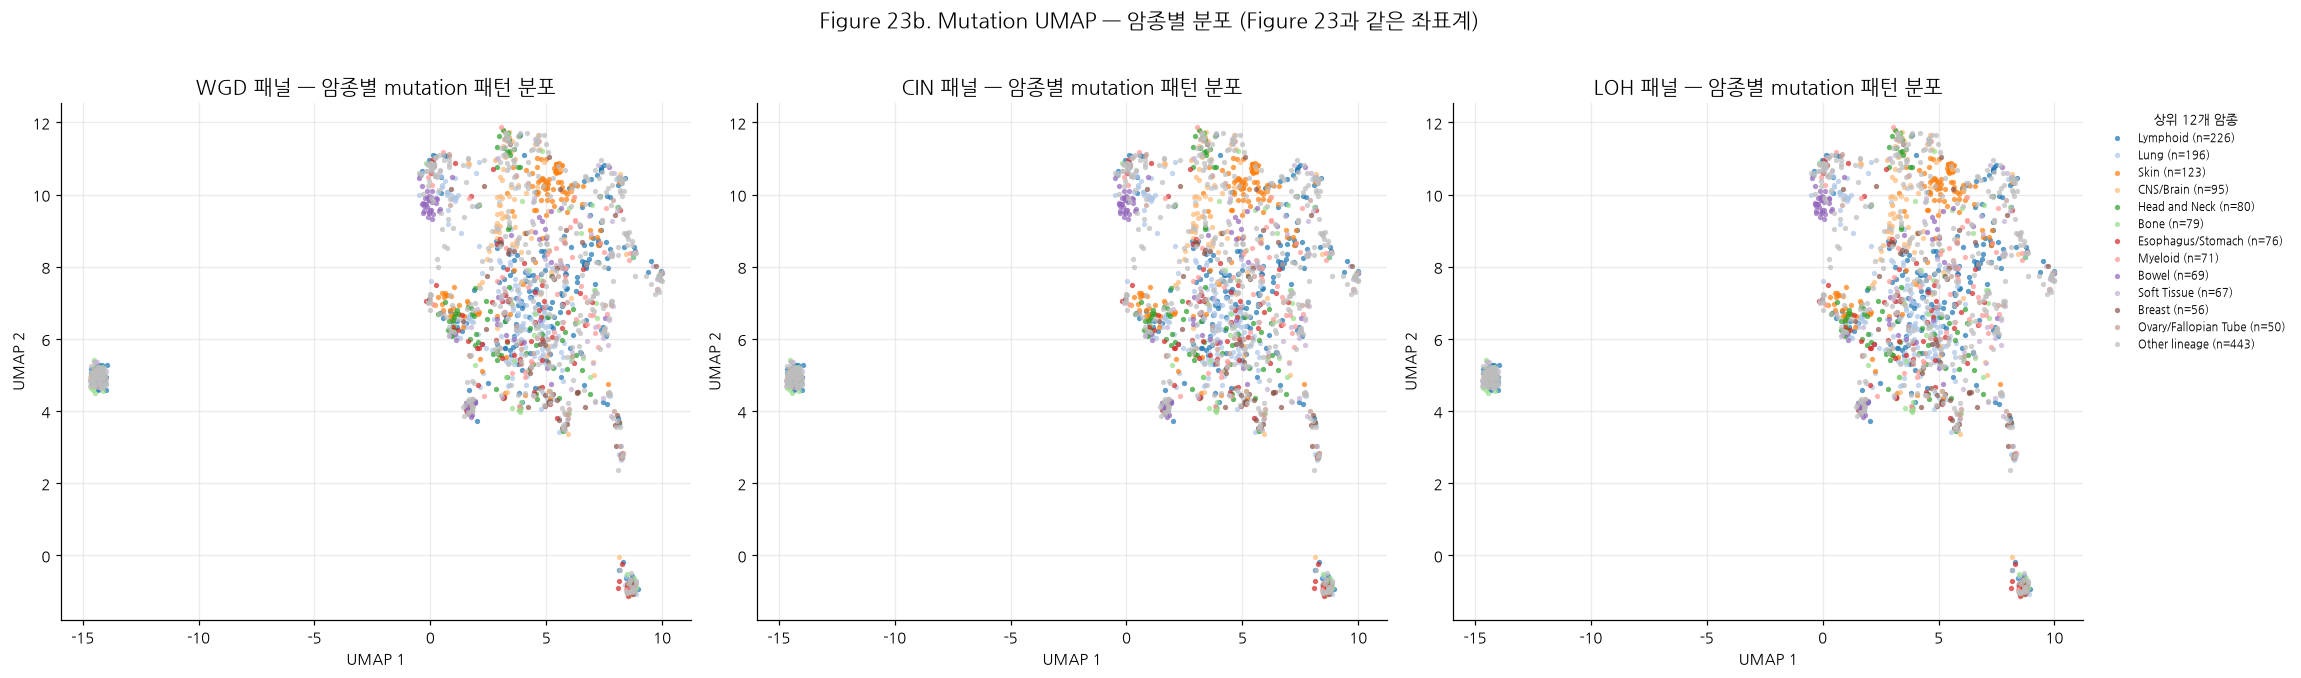

In [33]:
# Figure 23 / 23b — scripts/44_mutation_umap.py + 45_plot_mutation_umap.py
# UMAP 좌표를 여기서 직접 계산한다. umap-learn 이 없으면 커밋된 좌표 CSV 로 대체.
UMAP_FEATURES = 80
TOP_N_LINEAGES = 12

_keep = _prev[_prev >= MIN_PREVALENCE].sort_values(ascending=False)
X_umap = cohort_X.loc[:, _keep.index[:UMAP_FEATURES]]

try:
    import umap.umap_ as umap
    import warnings as _w
    with _w.catch_warnings():
        _w.simplefilter("ignore")
        _reducer = umap.UMAP(n_neighbors=20, min_dist=0.25, metric="jaccard", random_state=SEED)
        _xy = _reducer.fit_transform(X_umap.to_numpy(dtype=bool))
    umap_df = pd.DataFrame({"UMAP1": _xy[:, 0], "UMAP2": _xy[:, 1]}, index=cohort_X.index)
    for _t in TARGETS:
        umap_df[_t] = labels_bin[_t].values
    umap_df["lineage"] = cohort_groups.reindex(cohort_X.index).values
    print(f"UMAP 직접 계산 완료 — feature {X_umap.shape[1]}개, 세포주 {len(umap_df):,}개")
except ImportError:
    umap_df = pd.read_csv(TABLES / "day44_mutation_umap_coords.csv", index_col=0)
    print("umap-learn 미설치 — 커밋된 좌표(day44_mutation_umap_coords.csv)를 사용."
          "\n  직접 계산하려면: pip install 'umap-learn==0.5.6'")


def _padded(v, frac=0.05):
    lo, hi = float(np.nanmin(v)), float(np.nanmax(v))
    pad = max((hi - lo) * frac, 0.1)
    return lo - pad, hi + pad


x_lim, y_lim = _padded(umap_df.UMAP1.to_numpy()), _padded(umap_df.UMAP2.to_numpy())

# --- Figure 23. 표현형 상태별 ---
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
for ax, _t in zip(axes, TARGETS):
    lab = TARGET_LABEL[_t]
    status = umap_df[_t].map({0: f"{lab}-", 1: f"{lab}+"})
    for suffix, color in (("-", "#4f81bd"), ("+", "#e76f51")):
        idx = status.eq(f"{lab}{suffix}").to_numpy()
        ax.scatter(umap_df.UMAP1[idx], umap_df.UMAP2[idx], s=12, alpha=0.7,
                   color=color, label=f"{lab}{suffix} (n={idx.sum()})", linewidths=0)
    ax.set_title(f"{lab} 상태별 mutation 패턴 분포", fontsize=13)
    ax.set_xlabel("UMAP 1"); ax.set_ylabel("UMAP 2")
    ax.set_xlim(*x_lim); ax.set_ylim(*y_lim)
    ax.legend(fontsize=9)
fig.suptitle("Figure 23. Mutation UMAP — WGD·CIN·LOH 상태별 분포", y=1.02, fontsize=14)
fig.tight_layout()
plt.show()

# --- Figure 23b. 같은 좌표를 암종(lineage)별로 색칠 ---
import seaborn as sns

_counts = umap_df.lineage.value_counts()
_shown = _counts.head(TOP_N_LINEAGES).index
_grouped = umap_df.lineage.where(umap_df.lineage.isin(_shown), "Other lineage")
_groups = list(_shown) + ["Other lineage"]
_palette = dict(zip(_groups, sns.color_palette("tab20", len(_shown)).as_hex() + ["#bdbdbd"]))

fig, axes = plt.subplots(1, 3, figsize=(21, 6))
for ax, _t in zip(axes, TARGETS):
    for g in _groups:
        idx = _grouped.eq(g).to_numpy()
        ax.scatter(umap_df.UMAP1[idx], umap_df.UMAP2[idx], s=12, alpha=0.72,
                   color=_palette[g], label=f"{g} (n={idx.sum()})", linewidths=0)
    ax.set_title(f"{TARGET_LABEL[_t]} 패널 — 암종별 mutation 패턴 분포", fontsize=13)
    ax.set_xlabel("UMAP 1"); ax.set_ylabel("UMAP 2")
    ax.set_xlim(*x_lim); ax.set_ylim(*y_lim)
axes[-1].legend(bbox_to_anchor=(1.02, 1), loc="upper left", fontsize=7.5,
                title=f"상위 {TOP_N_LINEAGES}개 암종", title_fontsize=8.5)
fig.suptitle("Figure 23b. Mutation UMAP — 암종별 분포 (Figure 23과 같은 좌표계)",
             y=1.02, fontsize=14)
fig.tight_layout()
plt.show()

CCA correlations (이진화): 0.390, 0.169, 0.051
CCA correlation (연속값, component 1): 0.453


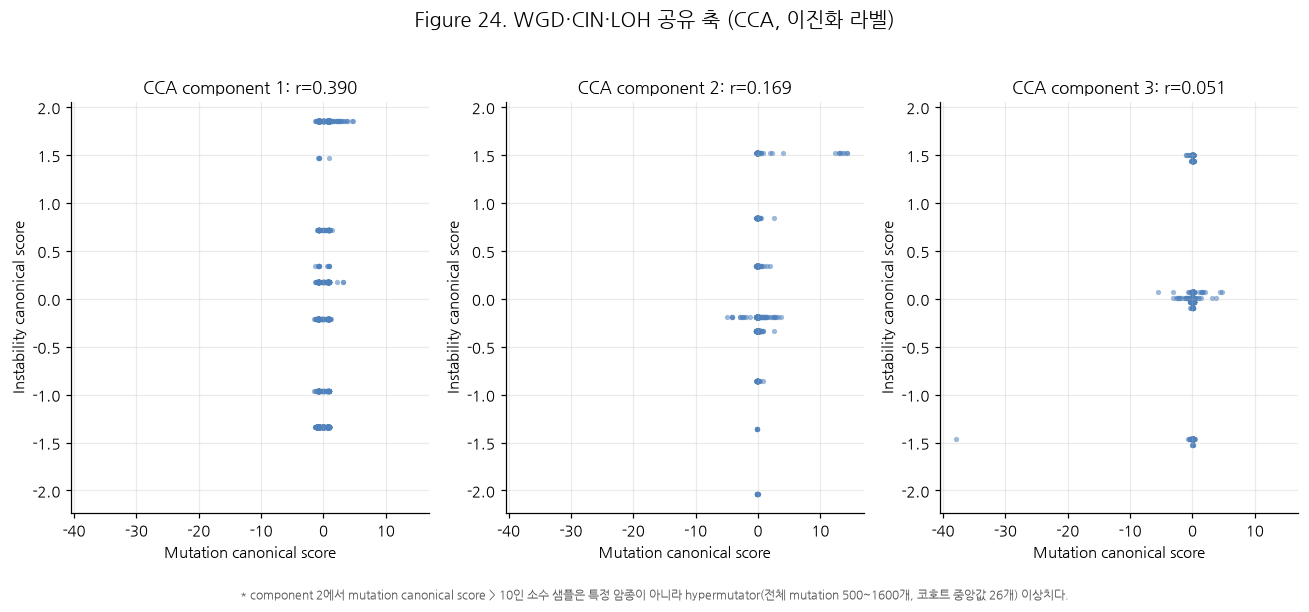

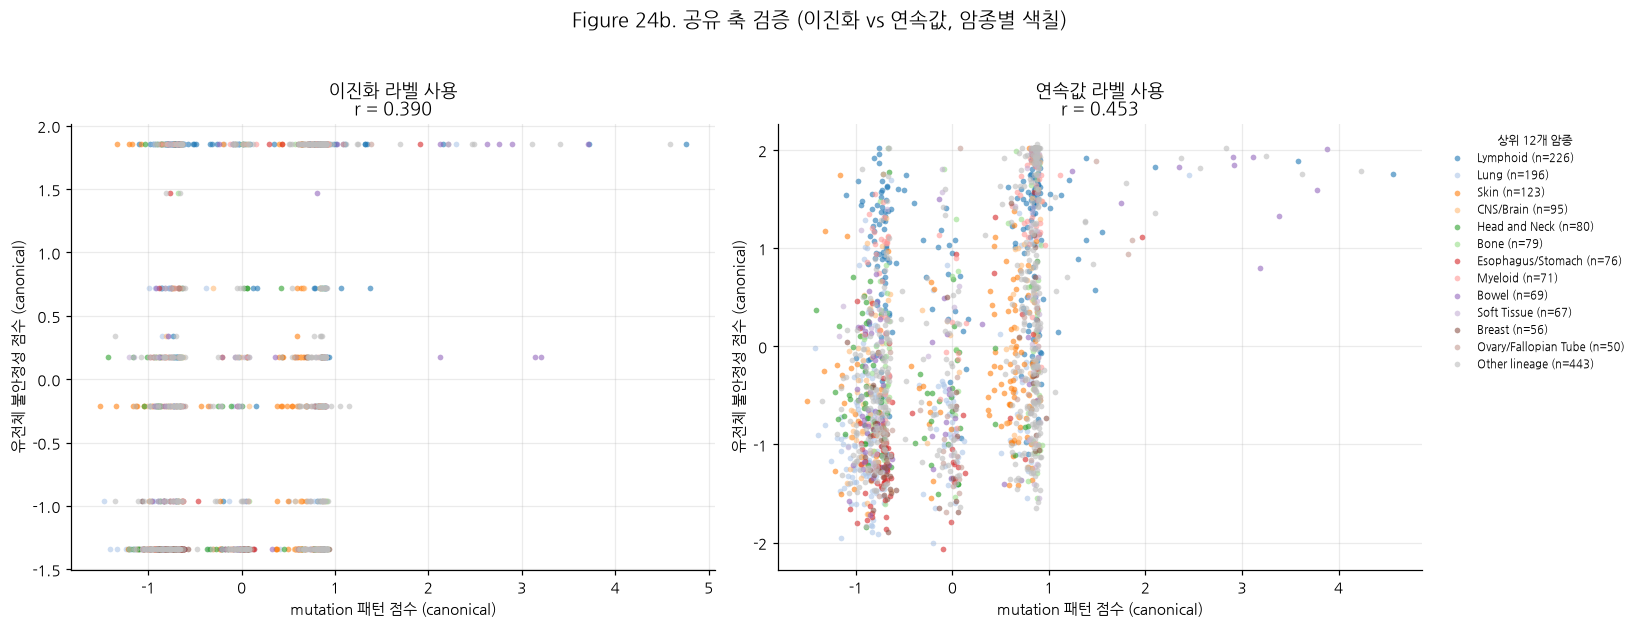

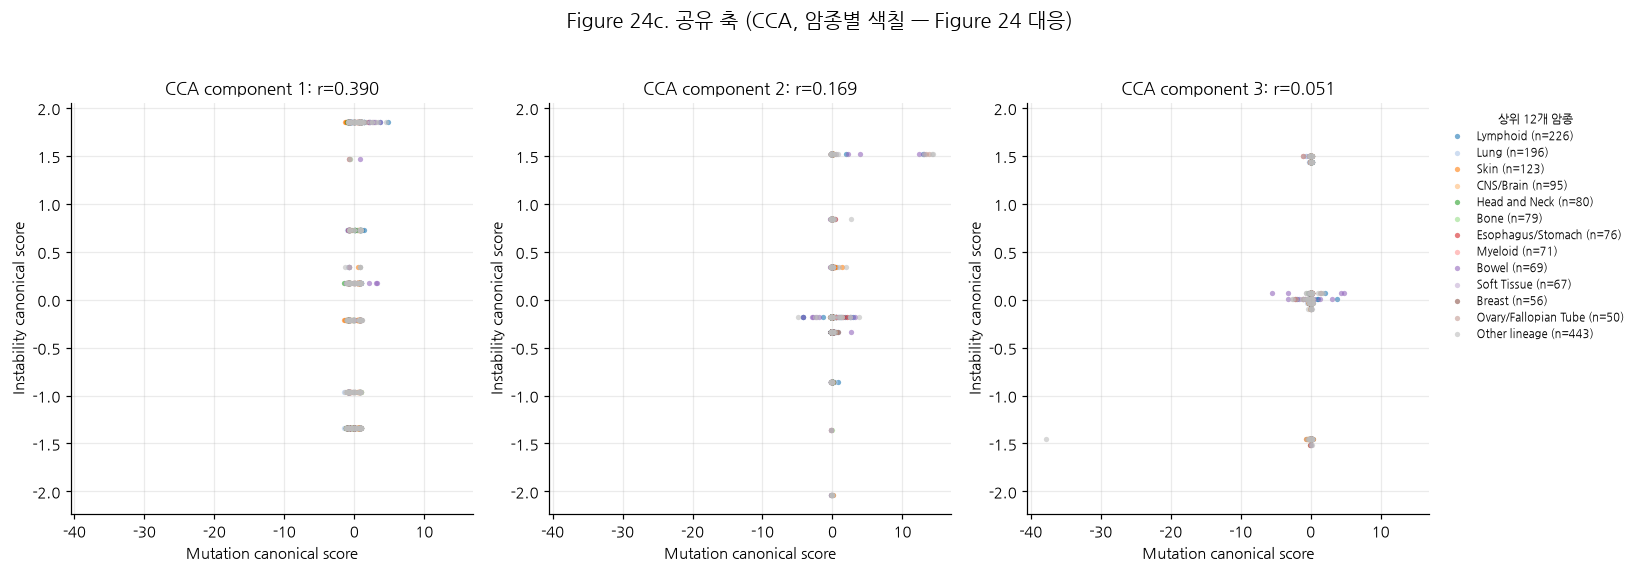

In [34]:
# Figure 24 / 24b / 24c — scripts/46_mutation_cca.py + 47_plot_mutation_cca.py
# SVD 로 sparse mutation 을 줄인 뒤 CCA 를 여기서 직접 계산한다.
from sklearn.cross_decomposition import CCA
from sklearn.decomposition import TruncatedSVD
from sklearn.preprocessing import StandardScaler

_n_svd = min(20, cohort_X.shape[1] - 1, cohort_X.shape[0] - 1)
_scores = TruncatedSVD(n_components=_n_svd, random_state=SEED).fit_transform(cohort_X)
_mut = StandardScaler().fit_transform(_scores)


def run_cca(Y_raw, n_components):
    Y = StandardScaler().fit_transform(Y_raw)
    U, V = CCA(n_components=n_components, max_iter=2000).fit_transform(_mut, Y)
    corr = [float(np.corrcoef(U[:, i], V[:, i])[0, 1]) for i in range(n_components)]
    return U, V, corr


U_bin, V_bin, corr_bin = run_cca(labels_bin[list(TARGETS)].to_numpy(), 3)
U_cont, V_cont, corr_cont = run_cca(cohort_y[list(TARGETS)].to_numpy(), 1)
print("CCA correlations (이진화):", ", ".join(f"{c:.3f}" for c in corr_bin))
print(f"CCA correlation (연속값, component 1): {corr_cont[0]:.3f}")

_xlim = _padded(U_bin[:, :3]); _ylim = _padded(V_bin[:, :3])

# --- Figure 24. component 별 산점도 ---
fig, axes = plt.subplots(1, 3, figsize=(12, 5))
for i, ax in enumerate(axes):
    ax.scatter(U_bin[:, i], V_bin[:, i], s=12, alpha=0.55, color="#4f81bd", linewidths=0)
    ax.set(title=f"CCA component {i + 1}: r={corr_bin[i]:.3f}",
           xlabel="Mutation canonical score", ylabel="Instability canonical score",
           xlim=_xlim, ylim=_ylim)
fig.suptitle("Figure 24. WGD·CIN·LOH 공유 축 (CCA, 이진화 라벨)", y=1.03, fontsize=13)
fig.text(0.5, -0.04,
         "* component 2에서 mutation canonical score > 10인 소수 샘플은 특정 암종이 아니라 "
         "hypermutator(전체 mutation 500~1600개, 코호트 중앙값 26개) 이상치다.",
         ha="center", fontsize=8, color="#555")
fig.tight_layout()
plt.show()

# --- Figure 24b. 이진화 vs 연속값, 암종별 색칠 ---
_lin = cohort_groups.reindex(cohort_X.index)
_cnt = _lin.value_counts()
_shown2 = _cnt.head(TOP_N_LINEAGES).index
_grp2 = _lin.where(_lin.isin(_shown2), "Other lineage")
_pal2 = dict(zip(list(_shown2) + ["Other lineage"],
                 sns.color_palette("tab20", len(_shown2)).as_hex() + ["#bdbdbd"]))

fig, axes = plt.subplots(1, 2, figsize=(15, 5.5))
for g, color in _pal2.items():
    idx = _grp2.eq(g).to_numpy()
    axes[0].scatter(U_bin[idx, 0], V_bin[idx, 0], s=14, alpha=0.6, color=color, linewidths=0)
    axes[1].scatter(U_cont[idx, 0], V_cont[idx, 0], s=14, alpha=0.6, color=color,
                    label=f"{g} (n={idx.sum()})", linewidths=0)
axes[0].set_title(f"이진화 라벨 사용\nr = {corr_bin[0]:.3f}", fontsize=12)
axes[1].set_title(f"연속값 라벨 사용\nr = {corr_cont[0]:.3f}", fontsize=12)
for ax in axes:
    ax.set_xlabel("mutation 패턴 점수 (canonical)")
    ax.set_ylabel("유전체 불안정성 점수 (canonical)")
axes[1].legend(bbox_to_anchor=(1.02, 1), loc="upper left", fontsize=7.5,
               title=f"상위 {TOP_N_LINEAGES}개 암종", title_fontsize=8)
fig.suptitle("Figure 24b. 공유 축 검증 (이진화 vs 연속값, 암종별 색칠)", y=1.03, fontsize=13)
fig.tight_layout()
plt.show()

# --- Figure 24c. Figure 24와 같은 3패널을 암종별로 색칠 ---
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
for i, ax in enumerate(axes):
    for g, color in _pal2.items():
        idx = _grp2.eq(g).to_numpy()
        ax.scatter(U_bin[idx, i], V_bin[idx, i], s=12, alpha=0.6, color=color,
                   label=f"{g} (n={idx.sum()})", linewidths=0)
    ax.set(title=f"CCA component {i + 1}: r={corr_bin[i]:.3f}",
           xlabel="Mutation canonical score", ylabel="Instability canonical score",
           xlim=_xlim, ylim=_ylim)
axes[-1].legend(bbox_to_anchor=(1.02, 1), loc="upper left", fontsize=7,
                title=f"상위 {TOP_N_LINEAGES}개 암종", title_fontsize=8)
fig.suptitle("Figure 24c. 공유 축 (CCA, 암종별 색칠 — Figure 24 대응)", y=1.03, fontsize=13)
fig.tight_layout()
plt.show()

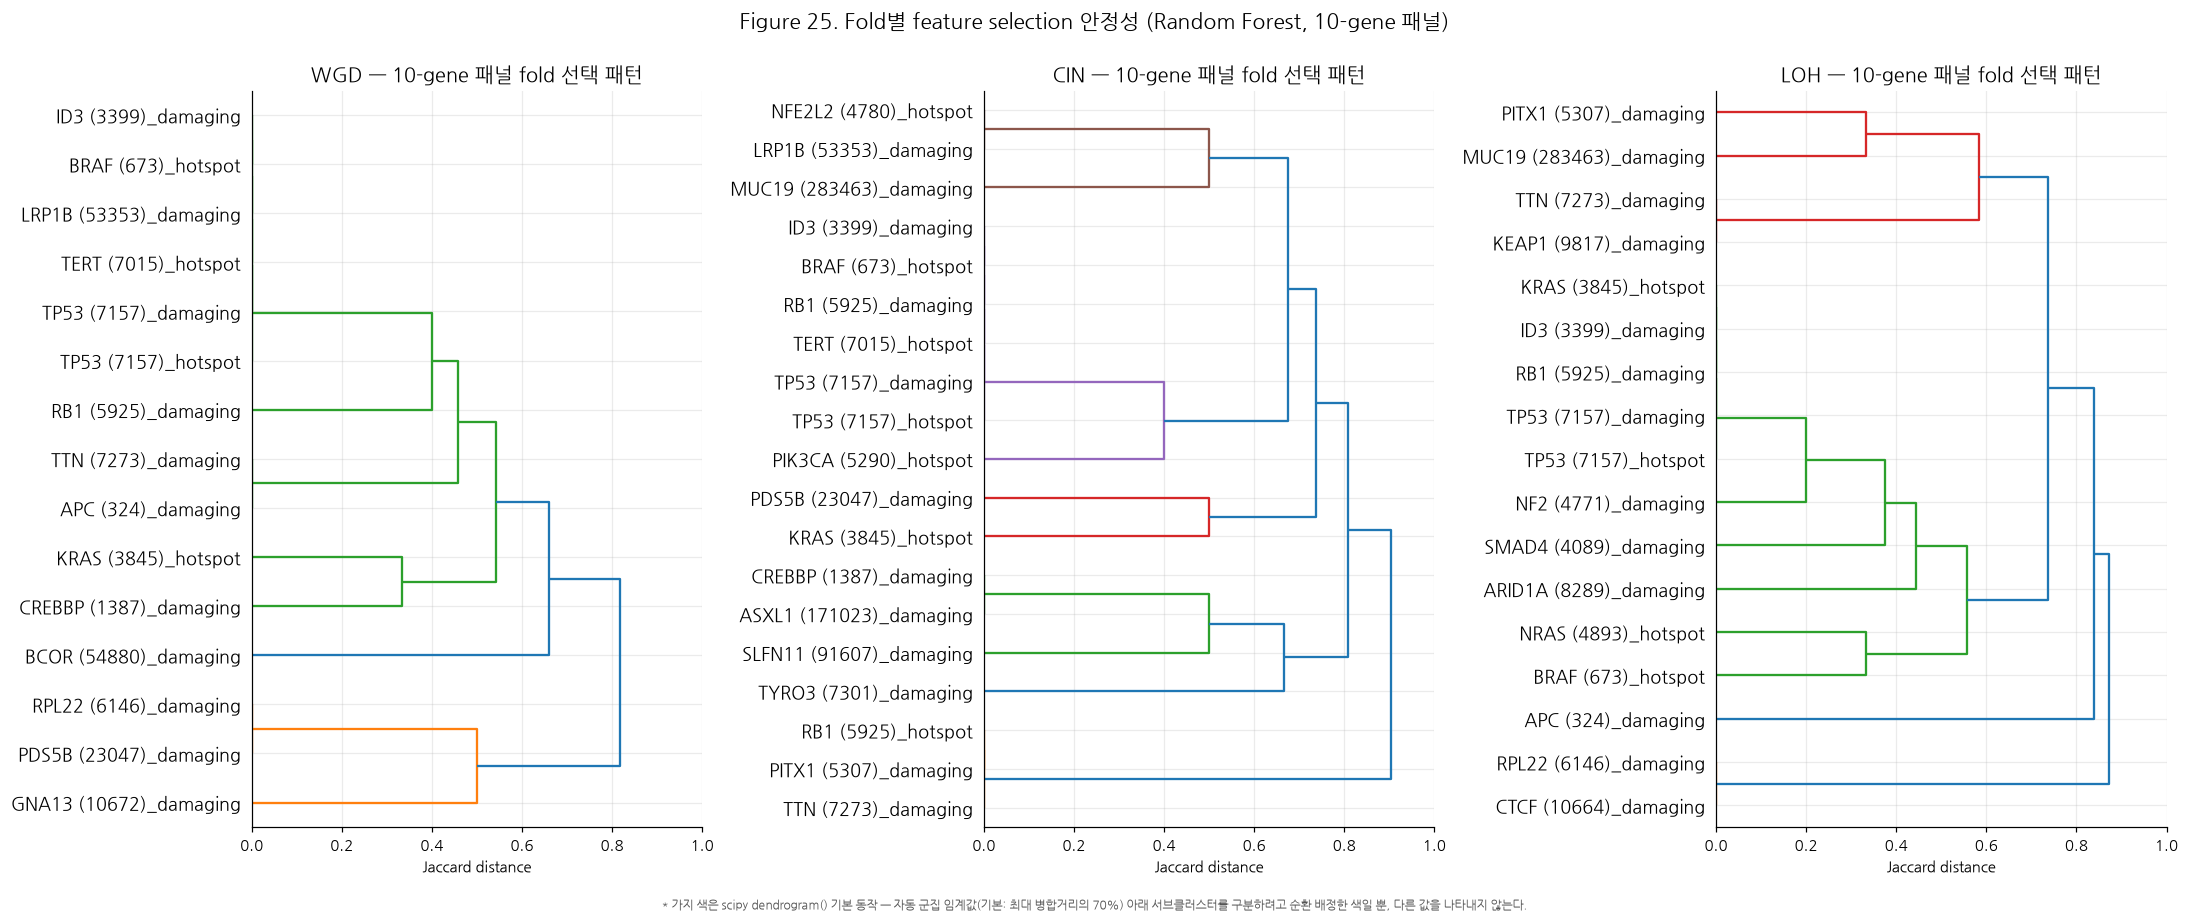

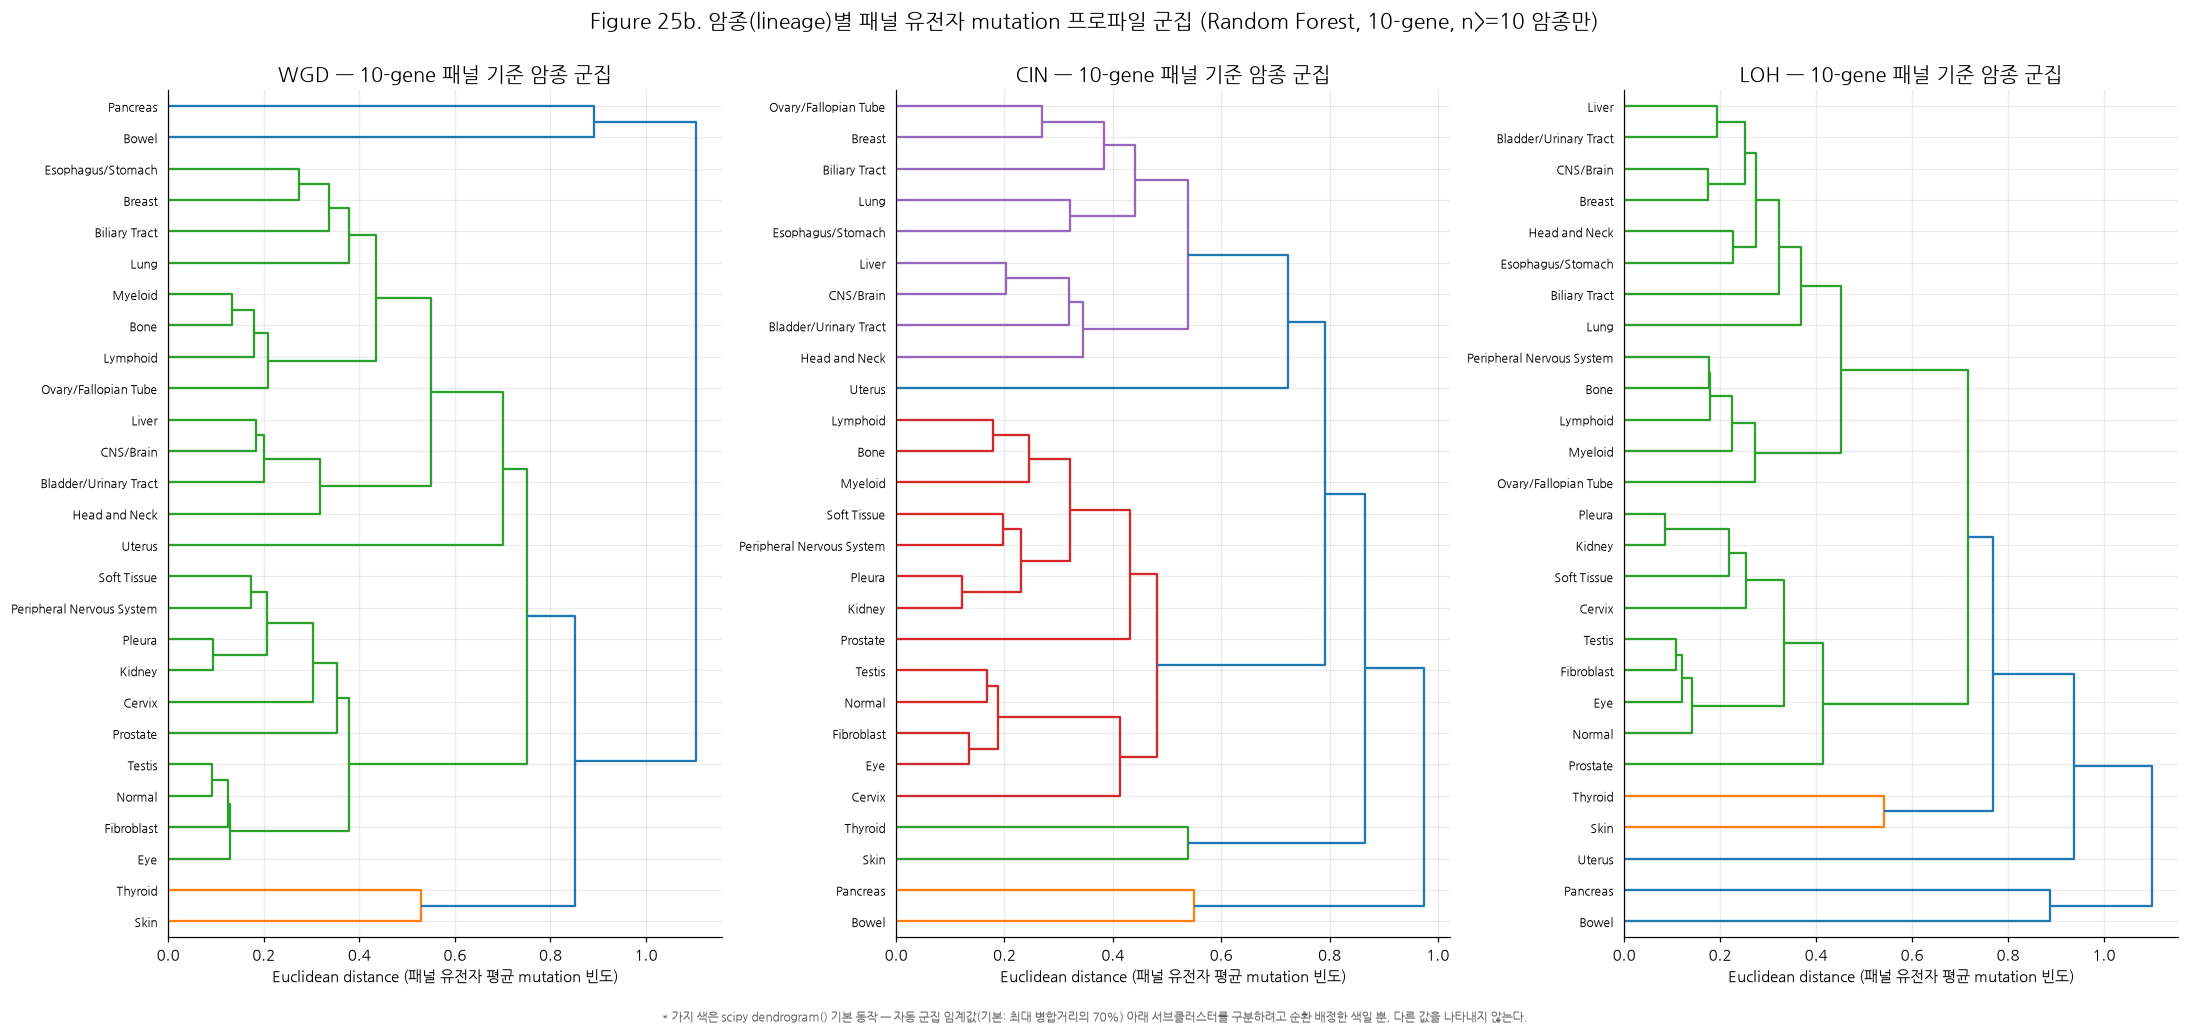

Figure 25c(암종별 co-mutation dendrogram, 8x3 그리드)는 크기가 커서 노트북에서는 생략했다.
  재현: python scripts/48_plot_selection_dendrogram.py


In [35]:
# Figure 25 / 25b — scripts/48_plot_selection_dendrogram.py
# Day 12 패널 결과(day12_panel_picks_*.csv)를 재사용해 계층군집화만 여기서 수행한다.
from scipy.cluster.hierarchy import dendrogram, linkage
from scipy.spatial.distance import pdist

PANEL_SIZE = 10
MIN_LINEAGE_N = 10
COLOR_NOTE = ("* 가지 색은 scipy dendrogram() 기본 동작 — 자동 군집 임계값(기본: 최대 병합거리의 70%) "
              "아래 서브클러스터를 구분하려고 순환 배정한 색일 뿐, 다른 값을 나타내지 않는다.")

_picks = pd.read_csv(TABLES / f"day12_panel_picks_random_forest.csv")

# --- Figure 25. fold 간 선택 패턴 (행=유전자, 열=fold) ---
fig, axes = plt.subplots(1, 3, figsize=(20, 8))
for ax, _t in zip(axes, TARGETS):
    sub = _picks[(_picks.target == _t) & (_picks.panel_size == PANEL_SIZE)]
    matrix = pd.crosstab(sub.feature, sub.fold).reindex(columns=sorted(sub.fold.unique()),
                                                        fill_value=0)
    dendrogram(linkage(pdist(matrix.to_numpy(), metric="jaccard"), method="average"),
               labels=matrix.index.tolist(), orientation="right", ax=ax)
    ax.set_title(f"{TARGET_LABEL[_t]} — {PANEL_SIZE}-gene 패널 fold 선택 패턴", fontsize=13)
    ax.set_xlabel("Jaccard distance")
    ax.set_xlim(0, 1)
fig.suptitle(f"Figure 25. Fold별 feature selection 안정성 (Random Forest, {PANEL_SIZE}-gene 패널)",
             y=1.0, fontsize=14)
fig.text(0.5, -0.02, COLOR_NOTE, ha="center", fontsize=8, color="#555")
fig.tight_layout()
plt.show()

# --- Figure 25b. 같은 3열, 행은 암종 (패널 유전자 평균 mutation 빈도로 군집) ---
_lcnt = cohort_groups.value_counts()
_keep_lin = _lcnt[_lcnt >= MIN_LINEAGE_N].index

fig, axes = plt.subplots(1, 3, figsize=(20, 9))
for ax, _t in zip(axes, TARGETS):
    genes = sorted(_picks[(_picks.target == _t) & (_picks.panel_size == PANEL_SIZE)]
                   .feature.unique())
    profile = cohort_X.loc[:, genes].groupby(cohort_groups).mean()
    profile = profile.loc[profile.index.isin(_keep_lin)]
    dendrogram(linkage(pdist(profile.to_numpy(), metric="euclidean"), method="average"),
               labels=profile.index.tolist(), orientation="right", ax=ax)
    ax.set_title(f"{TARGET_LABEL[_t]} — {PANEL_SIZE}-gene 패널 기준 암종 군집", fontsize=13)
    ax.set_xlabel("Euclidean distance (패널 유전자 평균 mutation 빈도)")
    ax.tick_params(axis="y", labelsize=8)
fig.suptitle(f"Figure 25b. 암종(lineage)별 패널 유전자 mutation 프로파일 군집 "
             f"(Random Forest, {PANEL_SIZE}-gene, n>={MIN_LINEAGE_N} 암종만)", y=1.0, fontsize=14)
fig.text(0.5, -0.02, COLOR_NOTE, ha="center", fontsize=8, color="#555")
fig.tight_layout()
plt.show()

print("Figure 25c(암종별 co-mutation dendrogram, 8x3 그리드)는 크기가 커서 노트북에서는 생략했다.")
print("  재현: python scripts/48_plot_selection_dendrogram.py")

## 15. 최종 후보 Biomarker Panel

지금까지의 모든 근거(fold 반복선택, 모델 간 합의, 회귀 재검증, TCGA 방향성
지지)를 종합한 최종 후보 8개 유전자다. 상세 근거표는
`docs/research/2026-08-19/biomarker_panel.md` 참고.

In [36]:
core_genes = ["TP53 (damaging+hotspot)", "ID3", "BRAF (hotspot)", "CREBBP"]
phenotype_specific = {
    "WGD": "TERT (hotspot)",
    "CIN": "RB1, PIK3CA (hotspot)",
    "LOH": "PITX1",
}
print("핵심 축 (3표현형 공통):", ", ".join(core_genes))
print()
for target, genes in phenotype_specific.items():
    print(f"  {target} 특이: {genes}")

핵심 축 (3표현형 공통): TP53 (damaging+hotspot), ID3, BRAF (hotspot), CREBBP

  WGD 특이: TERT (hotspot)
  CIN 특이: RB1, PIK3CA (hotspot)
  LOH 특이: PITX1


## 16. 결론 및 한계

- DNA mutation만으로 WGD/CIN/LOH를 ROC-AUC 0.73\~0.77 수준까지 예측 가능하다
  (acceptable 구간이나, 유병률 대비 이득·확률 보정은 제한적).
- Random Forest가 최고 성능이며, 핵심 신호는 TP53을 중심으로 소수 유전자에
  집중돼 있다.
- lineage(암종)를 분리하면 성능이 크게 떨어지고, 그 편차의 원인은 규명하지
  못했다.
- Pathway 재집계는 음성, mutation signature 표현은 양성 — "유전자 정체성"과
  "변이 발생 과정"은 서로 다른, 상보적인 정보다.
- TCGA 외부 검증은 방향은 유지되나 방법론적 한계로 하한 추정치에 그친다.
- 이 결과는 **candidate minimal mutation biomarker panel**이지 임상 확정
  바이오마커가 아니다.

전체 서술형 문서:
- `docs/research/2026-08-16/final_conclusion.md` (Day 1\~13 핵심 결론)
- `docs/research/2026-08-19/additional_results.md` (후속 실험 상세)
- `docs/research/2026-08-19/biomarker_panel.md` (최종 후보 패널 근거)
- `docs/research/2026-08-19/model.md` (모델 비교 상세)